# <center><strong>Music Recommendation System using Spotify</strong></center>


#### **By Mohamed Jamyl**

http://linkedin.com/in/mohamed-jamyl

https://www.kaggle.com/mohamedjamyl

https://github.com/Mohamed-Jamyl

-------------------------

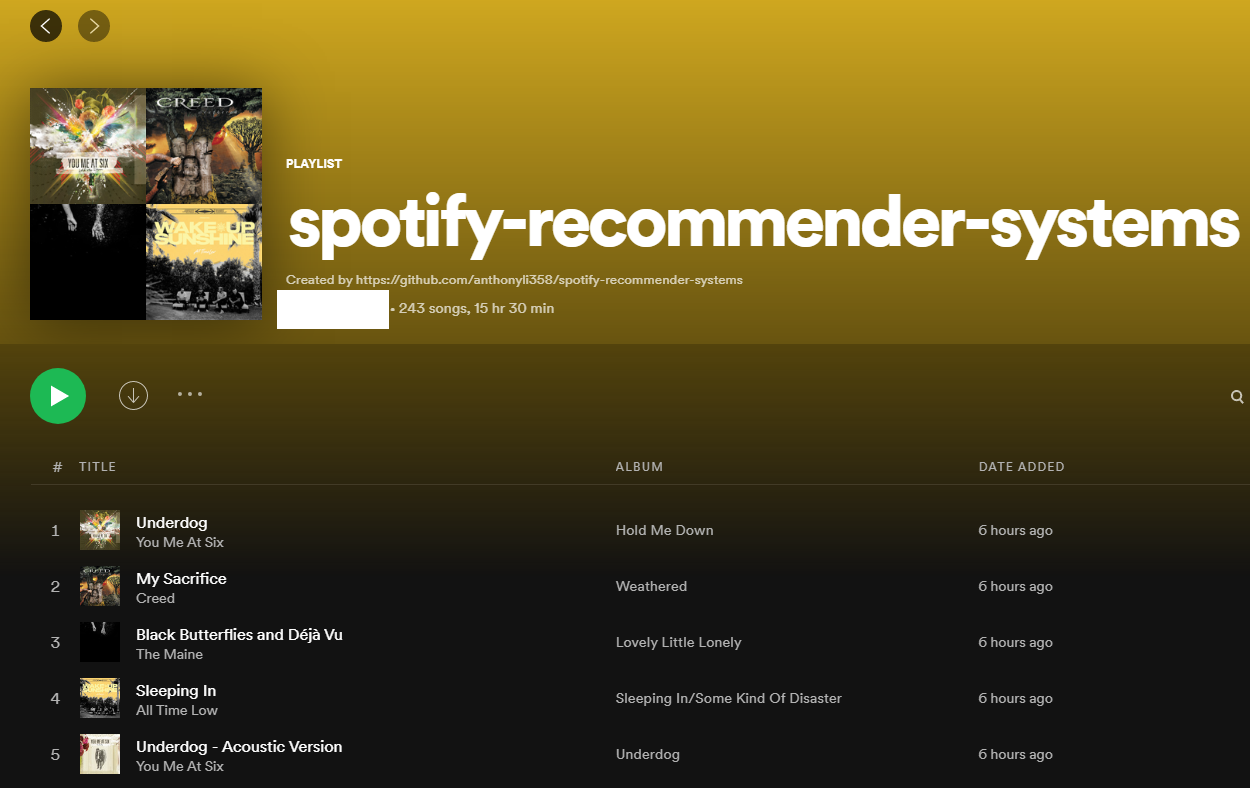

In [270]:
from IPython.display import Image
Image(filename='sp.png')

--------------------------------
--------------------------------
--------------------------------

## **Import Libraries**


In [271]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from keras.optimizers import Adam
from keras.models import Sequential 
from keras.layers import Dense
from keras.callbacks import EarlyStopping 
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor,RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from pickle import dump
from datetime import datetime
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

---------------------------------------
---------------------------------------
---------------------------------------

## **Exploratory Data Analysis (EDA)**

### **Initial Data Understanding**

 - **Data loading and Inspection**
 - **Data Types**
 - **Missing Values**
 - **Duplicates**

-------------------------

In [272]:
df = pd.read_csv('Music Recommendation System using Spotify Dataset.csv')

In [273]:
df

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.98200,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878000,10,0.6650,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.73200,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000000,7,0.1600,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.96100,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913000,3,0.1010,-14.850,1,Gati Bali,5,1921,0.0339,110.339
3,0.1650,1921,0.96700,['Frank Parker'],0.275,210000,0.309,0,3ftBPsC5vPBKxYSee08FDH,0.000028,5,0.3810,-9.316,1,Danny Boy,3,1921,0.0354,100.109
4,0.2530,1921,0.95700,['Phil Regan'],0.418,166693,0.193,0,4d6HGyGT8e121BsdKmw9v6,0.000002,3,0.2290,-10.096,1,When Irish Eyes Are Smiling,2,1921,0.0380,101.665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170648,0.6080,2020,0.08460,"['Anuel AA', 'Daddy Yankee', 'KAROL G', 'Ozuna...",0.786,301714,0.808,0,0KkIkfsLEJbrcIhYsCL7L5,0.000289,7,0.0822,-3.702,1,China,72,5/29/2020,0.0881,105.029
170649,0.7340,2020,0.20600,['Ashnikko'],0.717,150654,0.753,0,0OStKKAuXlxA0fMH54Qs6E,0.000000,7,0.1010,-6.020,1,Halloweenie III: Seven Days,68,10/23/2020,0.0605,137.936
170650,0.6370,2020,0.10100,['MAMAMOO'],0.634,211280,0.858,0,4BZXVFYCb76Q0Klojq4piV,0.000009,4,0.2580,-2.226,0,AYA,76,11/3/2020,0.0809,91.688
170651,0.1950,2020,0.00998,['Eminem'],0.671,337147,0.623,1,5SiZJoLXp3WOl3J4C8IK0d,0.000008,2,0.6430,-7.161,1,Darkness,70,1/17/2020,0.3080,75.055


In [274]:
df.shape

(170653, 19)

In [275]:
df.columns

Index(['valence', 'year', 'acousticness', 'artists', 'danceability',
       'duration_ms', 'energy', 'explicit', 'id', 'instrumentalness', 'key',
       'liveness', 'loudness', 'mode', 'name', 'popularity', 'release_date',
       'speechiness', 'tempo'],
      dtype='object')

In [276]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  object 
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  object 
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 non-null  object 
 15  popularity        170653 non-null  int64  
 16  release_date      17

In [277]:
df.isnull().sum()

valence             0
year                0
acousticness        0
artists             0
danceability        0
duration_ms         0
energy              0
explicit            0
id                  0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
name                0
popularity          0
release_date        0
speechiness         0
tempo               0
dtype: int64

In [278]:
df.duplicated().sum()

np.int64(0)

-----------------------------------------

### **Basic Statistical Overview**
-------------------------------------------
- Summary Statistical : **describe()**

In [279]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
valence,170653.0,0.528587,0.263171,0.0,0.3170,0.540000,0.7470,1.000
year,170653.0,1976.787241,25.917853,1921.0,1956.0000,1977.000000,1999.0000,2020.000
acousticness,170653.0,0.502115,0.376032,0.0,0.1020,0.516000,0.8930,0.996
danceability,170653.0,0.537396,0.176138,0.0,0.4150,0.548000,0.6680,0.988
duration_ms,170653.0,230948.310666,126118.414668,5108.0,169827.0000,207467.000000,262400.0000,5403500.000
energy,170653.0,0.482389,0.267646,0.0,0.2550,0.471000,0.7030,1.000
explicit,170653.0,0.084575,0.278249,0.0,0.0000,0.000000,0.0000,1.000
instrumentalness,170653.0,0.167010,0.313475,0.0,0.0000,0.000216,0.1020,1.000
key,170653.0,5.199844,3.515094,0.0,2.0000,5.000000,8.0000,11.000
liveness,170653.0,0.205839,0.174805,0.0,0.0988,0.136000,0.2610,1.000


In [280]:
df.select_dtypes(include='object').describe()

,artists,id,name,release_date
count,170653,170653,170653,170653
unique,34088,170653,133637,11244
top,['Эрнест Хемингуэй'],4BJqT0PrAfrxzMOxytFOIz,White Christmas,1945
freq,1211,1,73,1446


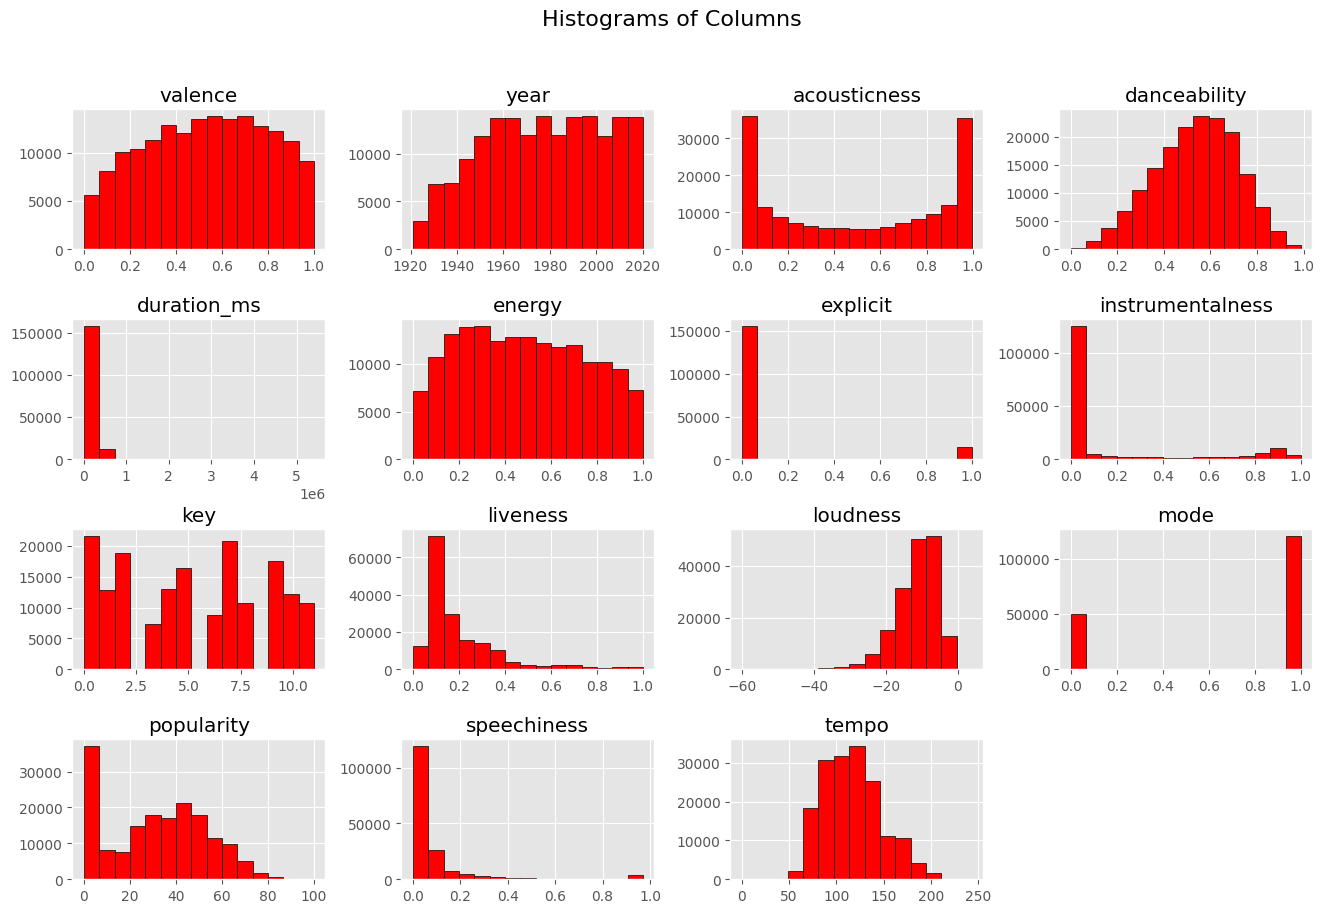

In [281]:
df.hist(bins=15, figsize=(16, 10), color='red', edgecolor='black')

# Set titles and labels for each subplot
plt.suptitle('Histograms of Columns', fontsize=16)
plt.subplots_adjust(hspace=0.5)  # Add space between plots
plt.show()

--------------------------------

- Summary Statistical : **value_counts()**

In [282]:
df["release_date"].value_counts()

release_date
1945         1446
1949         1247
1948         1127
1926         1099
1935         1078
             ... 
8/16/2018       1
3/27/2018       1
4/29/2018       1
8/29/2018       1
8/9/2018        1
Name: count, Length: 11244, dtype: int64

In [283]:
df['year'].value_counts()

year
2018    2103
2020    2030
2011    2017
2010    2016
2001    2005
        ... 
1925     278
1924     236
1923     185
1921     150
1922      71
Name: count, Length: 100, dtype: int64

In [284]:
df['explicit'].value_counts()

explicit
0    156220
1     14433
Name: count, dtype: int64

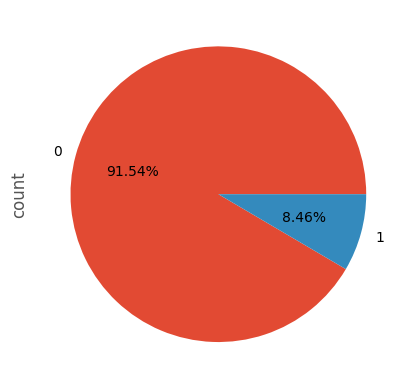

In [285]:
df['explicit'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

In [286]:
top20_songs=df['name'].value_counts().sort_values(ascending=False)[:20]
top20_songs

name
White Christmas       73
Winter Wonderland     63
Summertime            56
Jingle Bells          53
Overture              46
Silent Night          45
Home                  40
Silver Bells          36
The Christmas Song    36
Sleigh Ride           35
You                   33
Stay                  33
Forever               31
Autumn Leaves         31
Runaway               31
Hold On               31
Intro                 31
Stardust              30
I Love You            30
Angel                 30
Name: count, dtype: int64

In [287]:
nameDict = top20_songs.to_dict()
nameDict

{'White Christmas': 73,
 'Winter Wonderland': 63,
 'Summertime': 56,
 'Jingle Bells': 53,
 'Overture': 46,
 'Silent Night': 45,
 'Home': 40,
 'Silver Bells': 36,
 'The Christmas Song': 36,
 'Sleigh Ride': 35,
 'You': 33,
 'Stay': 33,
 'Forever': 31,
 'Autumn Leaves': 31,
 'Runaway': 31,
 'Hold On': 31,
 'Intro': 31,
 'Stardust': 30,
 'I Love You': 30,
 'Angel': 30}

In [288]:
song_names = [f'{i}' for i in top20_songs.keys()]
song_names

['White Christmas',
 'Winter Wonderland',
 'Summertime',
 'Jingle Bells',
 'Overture',
 'Silent Night',
 'Home',
 'Silver Bells',
 'The Christmas Song',
 'Sleigh Ride',
 'You',
 'Stay',
 'Forever',
 'Autumn Leaves',
 'Runaway',
 'Hold On',
 'Intro',
 'Stardust',
 'I Love You',
 'Angel']

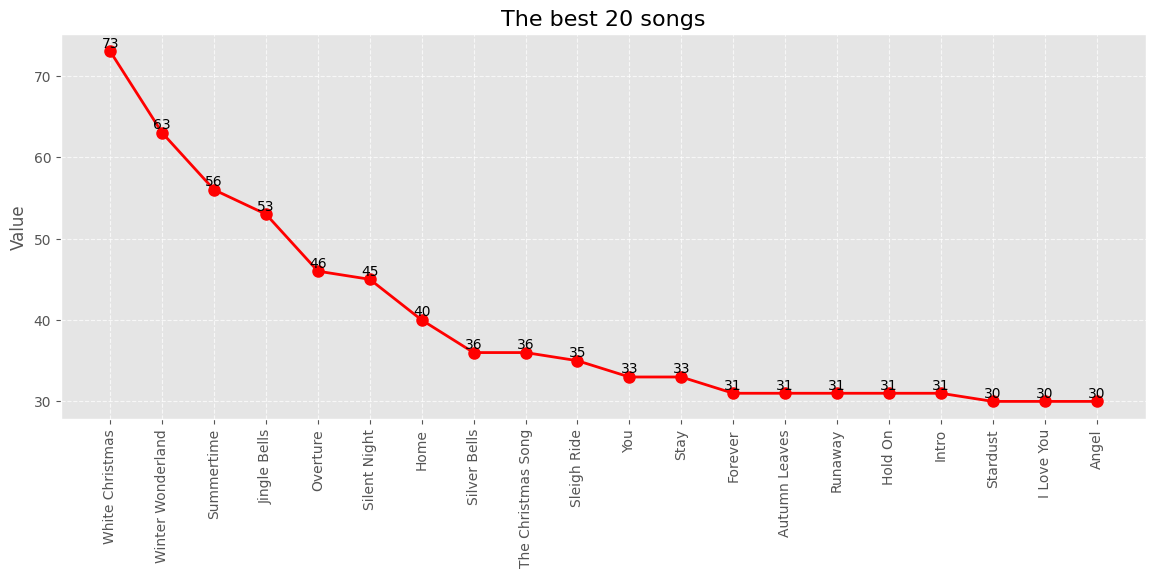

In [289]:
plt.style.use('ggplot')
plt.figure(figsize=(14, 5))

plt.plot(top20_songs, marker='o', color='red', linestyle='-', linewidth=2, markersize=8)
plt.xticks(ticks=range(len(song_names)), labels=song_names, rotation=90, fontsize=10)
plt.title('The best 20 songs', fontsize=16)
plt.ylabel('Value', fontsize=12)

for i, value in enumerate(top20_songs):
    plt.text(i, value + 0.5, str(round(value, 2)), ha='center', fontsize=10, color='black')

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

- ##### **Top Song**: "White Christmas" has the highest value, approximately 73.
- ##### **Rapid Initial Decline**: The value drops sharply from "White Christmas" to the next few songs: "Winter Wonderland" (around 63), "Summertime" (around 56), and "Jingle Bells" (around 53). This indicates a significant difference in value between the top song and the immediate runners-up.
- ##### **Gradual Decline**: After the initial sharp decrease, the value continues to decline more gradually across the remaining songs.
- ##### **Plateauing**: Around the 13th song ("Stay"), the values seem to plateau, hovering around the 30-31 range for the rest of the list. This suggests that the difference in value between these lower-ranked songs is relatively small.
- ##### **Specific Song Values**: The exact value for each of the top 20 songs is labeled directly above each data point, allowing for precise comparison. For example, "Overture" has a value of 46, "Silent Night" has 45, and "The Christmas Song" has 36.
#### **In summary**, this plot illustrates a clear ranking of the top 20 songs based on the "Value" metric. There's a significant drop-off from the top song, followed by a more gradual decline and then a plateau towards the lower end of the top 20.

------------------------------

In [290]:
top20MeanPopularity=[round(df[df['name']==i]['popularity'].mean()) for i in list(top20_songs.keys())]
top20MeanPopularity.sort()
print(top20MeanPopularity)

[11, 24, 27, 27, 29, 30, 30, 31, 31, 31, 32, 35, 42, 46, 48, 48, 48, 49, 49, 49]


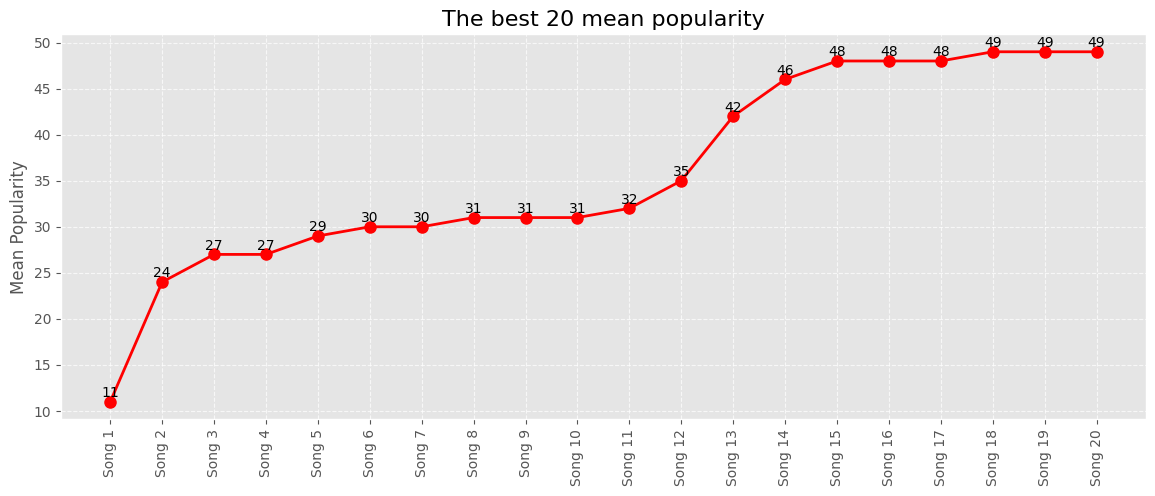

In [291]:
song_names = [f'Song {i+1}' for i in range(len(top20MeanPopularity))]

plt.style.use('ggplot')
plt.figure(figsize=(14, 5))

plt.plot(top20MeanPopularity, marker='o', color='red', linestyle='-', linewidth=2, markersize=8)
plt.xticks(ticks=range(len(song_names)), labels=song_names, rotation=90, fontsize=10)
plt.title('The best 20 mean popularity', fontsize=16)
plt.ylabel('Mean Popularity', fontsize=12)

for i, value in enumerate(top20MeanPopularity):
    plt.text(i, value + 0.5, str(round(value, 2)), ha='center', fontsize=10, color='black')

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### This is a line plot displaying the "Mean Popularity" of the top 20 songs. The songs are labeled as "Song 1" to "Song 20" along the x-axis, and their corresponding mean popularity scores are plotted on the y-axis. The title "The best 20 mean popularity" suggests these are the 20 songs with the highest average popularity according to the metric used.


- ##### **Increasing Trend**: Overall, there is an increasing trend in mean popularity as we move from "Song 1" to "Song 20". This indicates that "Song 20" has the highest mean popularity among the top 20.

- ##### **Lowest Mean Popularity**: "Song 1" has the lowest mean popularity among the top 20, with a score of approximately 11.24.

- ##### **Gradual Increase in the Middle**: From "Song 2" to "Song 12", the mean popularity increases relatively gradually, fluctuating between the low 20s and low 30s.

- ##### **Significant Increase Towards the End**: There is a more substantial increase in mean popularity starting around "Song 13" (with a score of 41.84) and continuing towards "Song 20" (with a score of 49.24). This suggests a clearer distinction in popularity among the top few songs.

- ##### **Specific Mean Popularity Scores**: The exact mean popularity score for each of the top 20 songs is labeled directly above each data point, allowing for precise comparison. For example, "Song 5" has a mean popularity of 29.45, "Song 10" has 30.84, and "Song 17" has 47.82.

#### **In summary**, this plot illustrates the mean popularity scores of the top 20 songs, showing an overall increasing trend with a more significant rise in popularity for the highest-ranked songs.

---------------------------------------

In [292]:
top20_artist = df['artists'].value_counts().sort_values(ascending=False)[:20]
top20_artist

artists
['Эрнест Хемингуэй']                   1211
['Эрих Мария Ремарк']                  1068
['Francisco Canaro']                    942
['Frank Sinatra']                       630
['Ignacio Corsini']                     628
['Elvis Presley']                       504
['Johnny Cash']                         484
['Bob Dylan']                           474
['The Rolling Stones']                  471
['The Beach Boys']                      455
['Francisco Canaro', 'Charlo']          453
['Fleetwood Mac']                       437
['Dean Martin']                         420
['The Beatles']                         407
['Queen']                               406
['Billie Holiday']                      404
['Georgette Heyer', 'Irina Salkow']     395
['Miles Davis']                         394
['Ella Fitzgerald']                     365
['Lead Belly']                          337
Name: count, dtype: int64

---------------------------------------
---------------------------------------

### **Checking Correlation between the features**

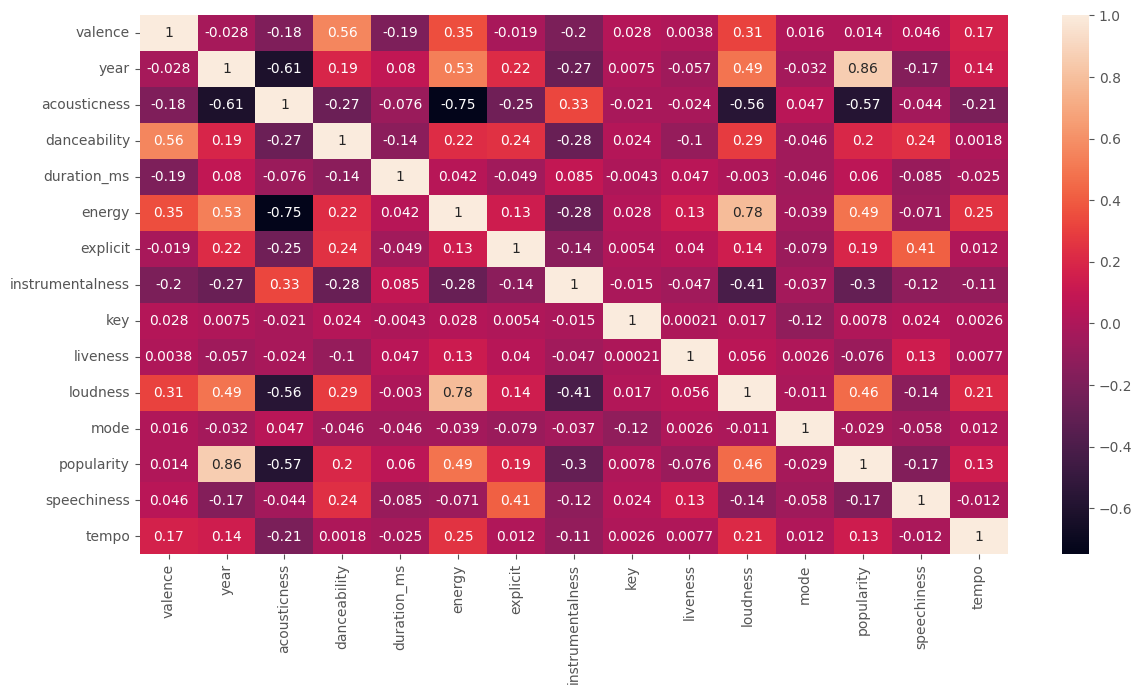

In [293]:
plt.figure(figsize=(14,	7))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.show()

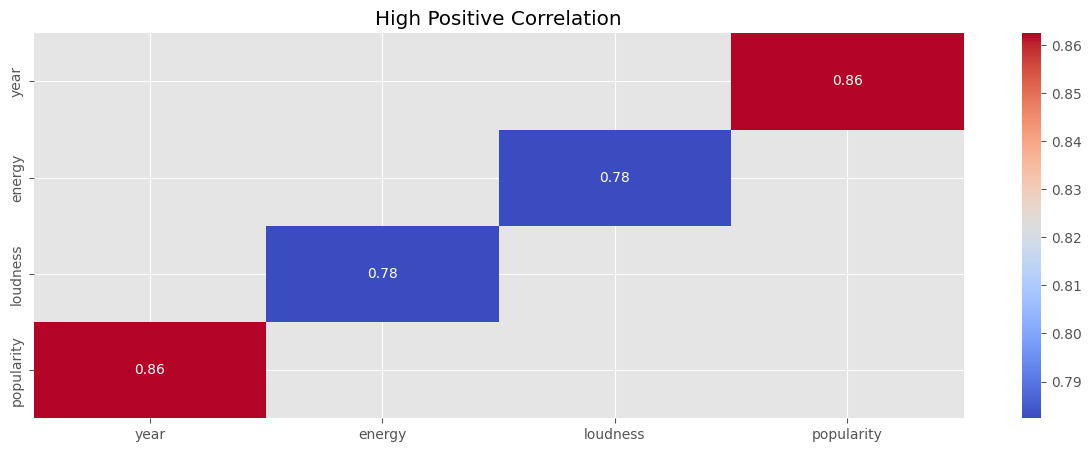

In [294]:
# function to extract high positive correlated columns
def get_high_corr(df, threshold):
    corr = df.select_dtypes('number').corr()
    high_corr = corr[(corr >= threshold) & (corr != 1.000)]
    high_corr = high_corr.dropna(how='all', axis=1).dropna(how='all', axis=0)
    return high_corr

# get high positive correlated columns
high_corr = get_high_corr(df, 0.7)

# plot high positive correlated columns
plt.figure(figsize=(15, 5))
plot = sns.heatmap(high_corr, annot=True, cmap='coolwarm')
plot.set_title('High Positive Correlation')
plt.show()

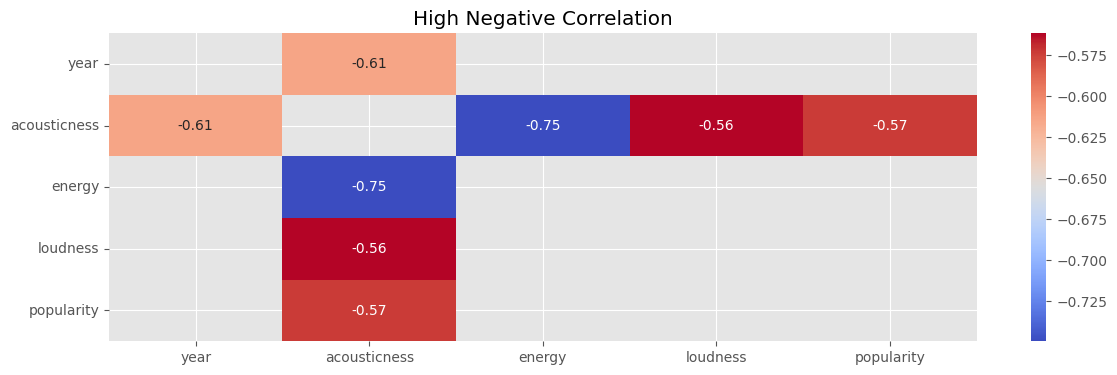

In [295]:
# function to extract high negative correlated columns
def get_high_corr(df, threshold):
    corr = df.select_dtypes('number').corr()
    high_corr = corr[(corr <= threshold) & (corr != 1.000)]
    high_corr = high_corr.dropna(how='all', axis=1).dropna(how='all', axis=0)
    return high_corr

# get high negative correlated columns
high_corr = get_high_corr(df, -0.5)

# plot high negative correlated columns
plt.figure(figsize=(14, 4))
plot = sns.heatmap(high_corr, annot=True, cmap='coolwarm')
plot.set_title('High Negative Correlation')
plt.show()

#### **Correlation Range** : The color intensity and the numerical values indicate the strength and direction of the linear relationship between pairs of features. Values close to 1 signify a strong positive correlation, values close to -1 indicate a strong negative correlation, and values near 0 suggest a weak or no linear correlation.

#### **Diagonal**: The diagonal shows a perfect positive correlation (1) for each feature with itself, as expected.

#### **Key Correlations**:

- ##### **Acousticness and Energy (-0.75)**: There's a strong negative correlation between acousticness and energy. This suggests that songs with higher acousticness tend to have lower energy levels, and vice versa.
- ##### **Acousticness and Loudness (-0.56)**: A moderate negative correlation exists between acousticness and loudness, indicating that more acoustic songs tend to be quieter.
- ##### **Acousticness and Popularity (-0.57)**: There's a moderate negative correlation between acousticness and popularity, suggesting that more acoustic songs tend to be less popular, or vice versa, within this dataset.
- ##### **Danceability and Energy (0.56)**: A moderate positive correlation exists between danceability and energy, implying that more danceable songs tend to have higher energy levels.
- ##### **Loudness and Energy (0.78)**: A strong positive correlation between loudness and energy indicates that louder songs tend to have higher energy levels.
- ##### **Popularity and Year (0.86)**: A very strong positive correlation between popularity and year suggests that more recent songs in this dataset tend to be more popular. This could reflect trends in music taste or the nature of the dataset.
- ##### **Instrumentalness and Acousticness (0.33)**: A weak positive correlation suggests that instrumental songs might have a slight tendency to be more acoustic.
- ##### **Speechiness and Acousticness (0.44)**: A moderate positive correlation indicates that songs with more spoken words tend to be more acoustic.
- ##### **Weak Correlations**: Many other pairs of features show correlations closer to zero, indicating a weak or negligible linear relationship. For example, the correlation between 'valence' and 'year' is -0.028, suggesting almost no linear association.

#### **In Summary**:

- ##### Acousticness has strong negative correlations with energy and loudness, and a moderate negative correlation with popularity.
- ##### Danceability is moderately positively correlated with energy.
- ##### Loudness and energy have a strong positive correlation.
- ##### Popularity shows a very strong positive correlation with the year of the song.
- ##### Instrumentalness and speechiness show weak to moderate positive correlations with acousticness.
- ##### Many other feature pairs have weak linear relationships.

------------------------------

In [296]:
# plot scatter plot for high correlated columns
def scatter(df, x, y, title):
    plt.figure(figsize=(14, 4))
    ax = sns.scatterplot(x=x, y=y, data=df)
    ax.set_title(title)
    plt.show()

- ##### There is a high positive correlation (0.86) between **year** and **popularity**

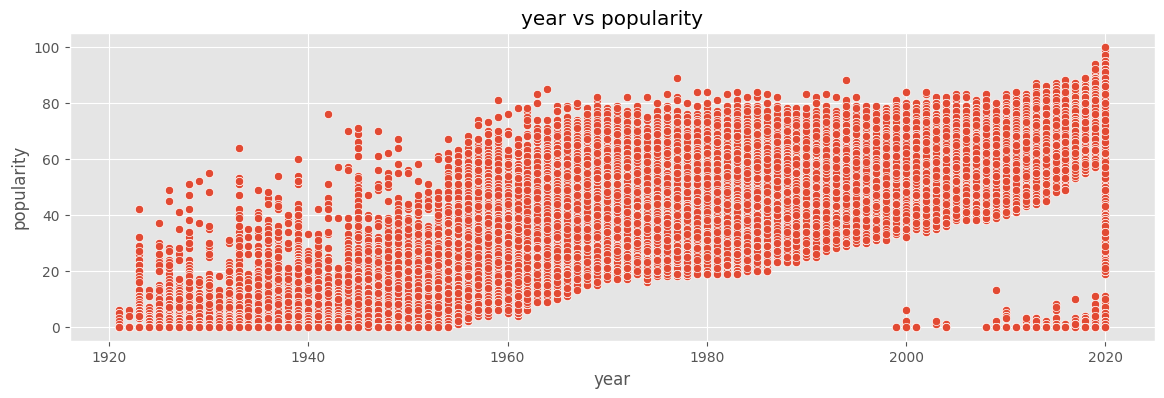

In [297]:
scatter(df, 'year', 'popularity', 'year vs popularity')

-------------------------------------

- ##### There is a high positive correlation (0.78) between **energy** and **loudness**  

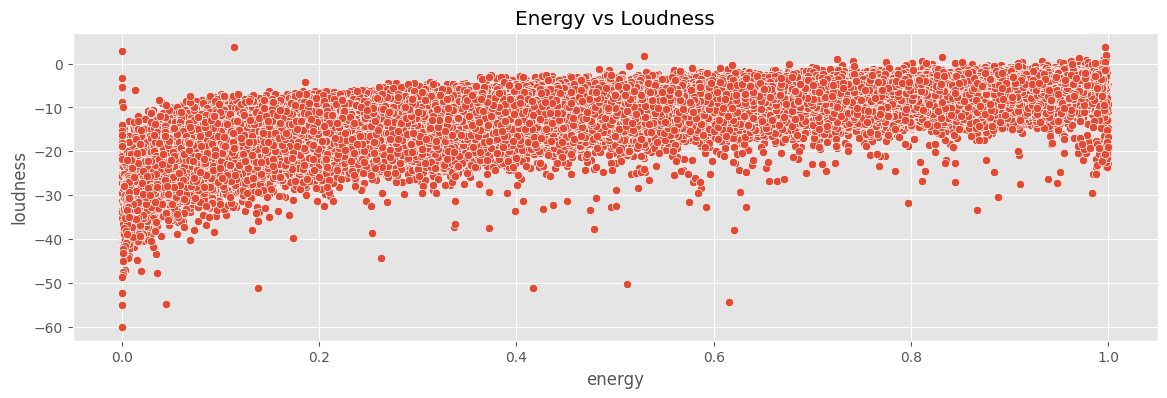

In [298]:
scatter(df, 'energy', 'loudness', 'Energy vs Loudness')

---------------------------------
---------------------------------

## **Detect Outliers**

-------------------------

In [299]:
df['popularity'].describe()

count    170653.000000
mean         31.431794
std          21.826615
min           0.000000
25%          11.000000
50%          33.000000
75%          48.000000
max         100.000000
Name: popularity, dtype: float64

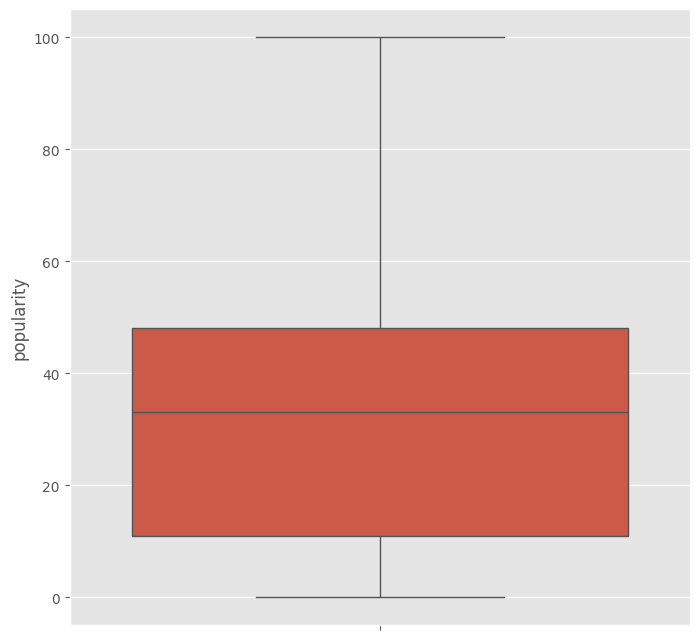

In [300]:
fig, axes = plt.subplots(nrows=1,ncols=1)
fig.set_size_inches(8, 8)
sns.boxplot(data=df,y="popularity",orient="v",ax=axes)
plt.show()

#### **The Box (Interquartile Range - IQR)**: The blue box represents the middle 50% of the popularity scores.

- ##### The bottom edge of the box indicates the first quartile (Q1), meaning 25% of the songs have a popularity score below approximately 11.
- ##### The top edge of the box indicates the third quartile (Q3), meaning 75% of the songs have a popularity score below approximately 48.
- ##### The line inside the box represents the median (Q2), which is the middle popularity score. In this case, the median popularity is around 33.
- ##### **The Whiskers**: The lines extending from the top and bottom of the box are called whiskers. They typically extend to 1.5 times the IQR from the quartiles.

- ##### The lower whisker extends down to the lowest data point that is not considered an outlier, which is approximately 0.
- ##### The upper whisker extends up to the highest data point that is not considered an outlier, which is approximately 100.
- ##### **Outliers**: There are no circles visible above the upper whisker, which suggests that there are no data points considered outliers on the higher end of the popularity spectrum based on the standard 1.5 * IQR rule.

#### **In summary**, this box plot tells us that:

- ##### The majority of songs in your dataset have a popularity score between approximately 11 and 48.
- ##### The median popularity score is around 33.
- ##### The popularity scores range from 0 to 100, with no apparent high-end outliers according to the typical definition.
- ##### The distribution appears to be somewhat right-skewed, as the median is closer to the first quartile than the third, suggesting a longer tail towards higher popularity scores.

----------------------------

#### **Target Variable Analysis**
#### **Relationship with Predictors (scatter plots or box Plots against the target)**

C:\Users\RPC\AppData\Local\Temp\ipykernel_18560\385351512.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=filtered_df['valence'], y=filtered_df['popularity'], palette="Set2")


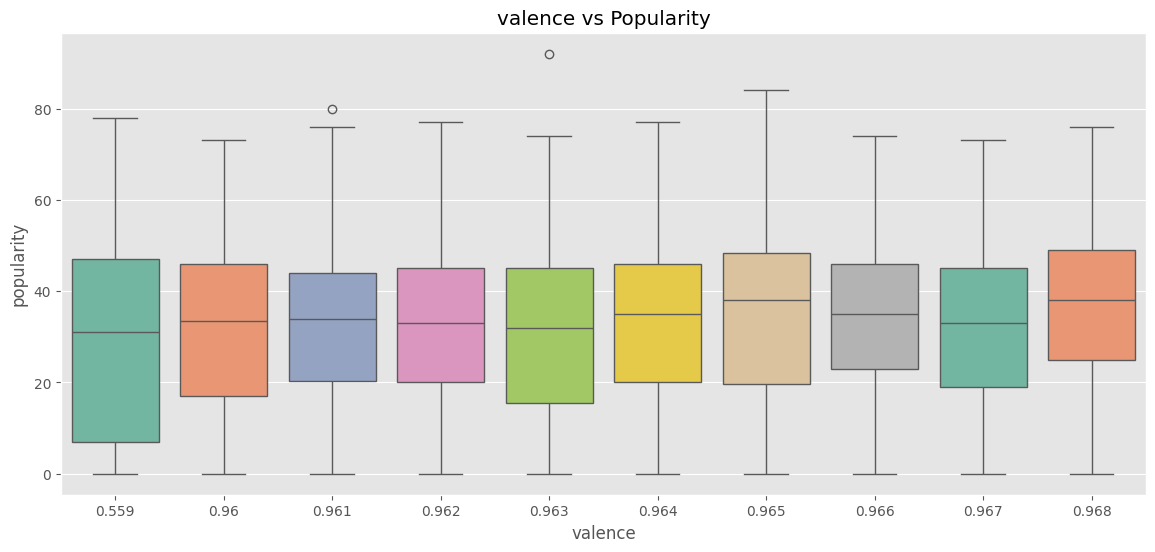

In [301]:
top_10_categs = df['valence'].value_counts().index[:10]
filtered_df = df[df['valence'].isin(top_10_categs)]

plt.figure(figsize=(14, 6))

sns.boxplot(x=filtered_df['valence'], y=filtered_df['popularity'], palette="Set2")

plt.title(f'valence vs Popularity')
plt.show()

#### This is a box plot visualizing the relationship between the 'valence' of songs and their 'popularity'. However, the x-axis, labeled 'valence', seems to display a few specific, very high valence values rather than a continuous range. This suggests that the data might have been grouped or filtered to show the distribution of popularity for songs with these particular high valence scores.

#### **Observations based on the plot**:

- ##### **Varied Popularity for High Valence Songs**: Across all the displayed high valence levels, there is a considerable range of popularity scores, as indicated by the height of the boxes and the length of the whiskers. This suggests that even among songs with high musical positiveness, their popularity can vary significantly.

- ##### **Relatively Similar Median Popularity**: The median popularity (the line inside each box) appears to be somewhat consistent across the different high valence levels, generally falling in the range of approximately 25 to 40. This might suggest that very high valence alone doesn't guarantee very high or very low median popularity.

- ##### **Presence of Outliers**: For several of the high valence levels, there are outlier songs with notably higher popularity scores (above the upper whisker). This indicates that some highly positive songs can achieve significant popularity.

- ##### **Spread of Popularity**: The interquartile range (the height of the boxes) varies slightly across the different valence levels, indicating different levels of spread or variability in popularity for songs within those specific high valence ranges.

--------------------------------

C:\Users\RPC\AppData\Local\Temp\ipykernel_18560\3967161567.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=filtered_df['energy'], y=filtered_df['popularity'], palette="Set2")


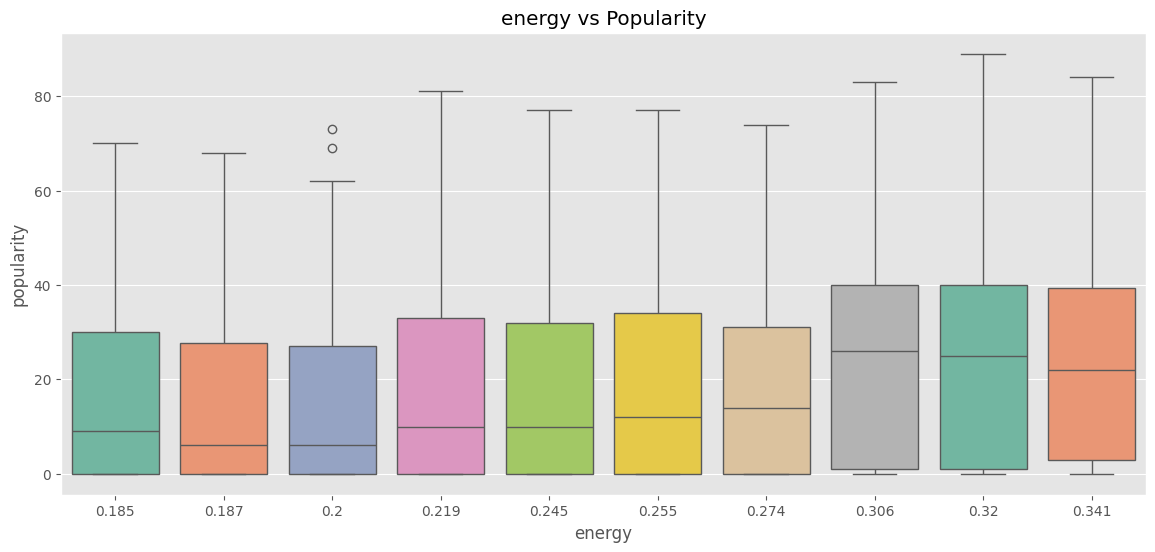

In [302]:
top_10_categs = df['energy'].value_counts().index[:10]
filtered_df = df[df['energy'].isin(top_10_categs)]

plt.figure(figsize=(14, 6))

sns.boxplot(x=filtered_df['energy'], y=filtered_df['popularity'], palette="Set2")

plt.title(f'energy vs Popularity')
plt.show()

#### As we discussed before, this is a box plot visualizing the relationship between the 'energy' of songs and their 'popularity'. The x-axis displays a few specific, relatively low energy values, and the y-axis shows the distribution of popularity for songs at each of those energy levels.

- ##### **Varied Popularity for Low Energy Songs**: Across the displayed low energy levels, the popularity scores show a considerable range, indicating that low energy doesn't uniformly translate to low or high popularity.

- ##### **Generally Low Median Popularity**: The median popularity for these low-energy song groups tends to be on the lower side (mostly below 20-25).

- ##### **Outliers Indicate Potential for Higher Popularity**: Despite the general trend, there are outlier songs with much higher popularity scores within some of these low-energy groups, suggesting that some low-energy tracks can still achieve significant popularity.

- ##### **Spread of Popularity Varies**: The height of the boxes (IQR) differs across the energy levels, indicating varying degrees of consistency in popularity within each group of low-energy songs.

-----------------------

C:\Users\RPC\AppData\Local\Temp\ipykernel_18560\119823950.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=filtered_df['acousticness'], y=filtered_df['popularity'], palette="Set2")


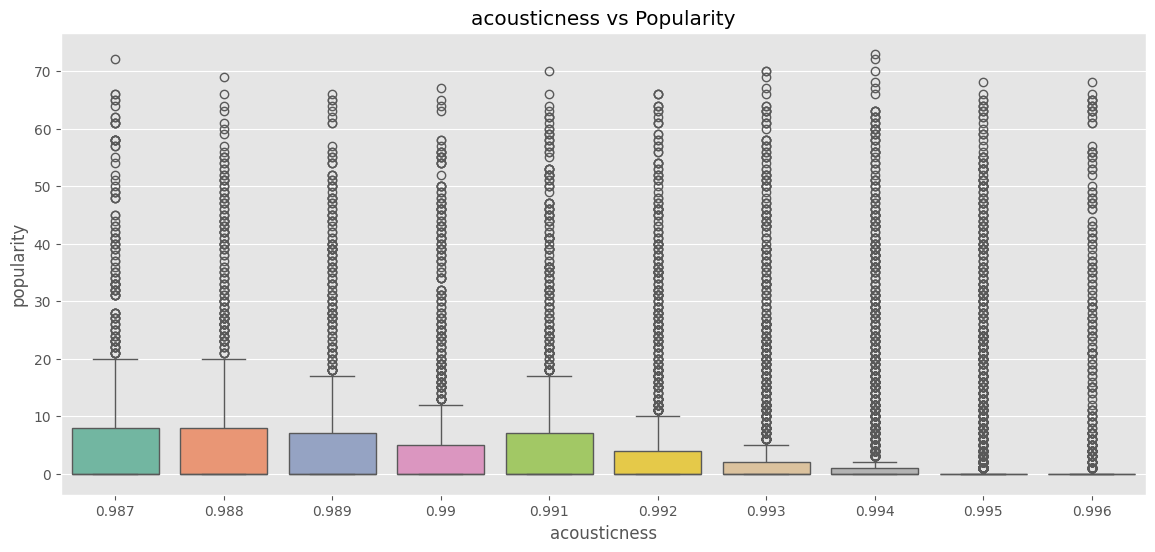

In [303]:
top_10_categs = df['acousticness'].value_counts().index[:10]
filtered_df = df[df['acousticness'].isin(top_10_categs)]

plt.figure(figsize=(14, 6))

sns.boxplot(x=filtered_df['acousticness'], y=filtered_df['popularity'], palette="Set2")

plt.title(f'acousticness vs Popularity')
plt.show()

#### This is a box plot visualizing the relationship between the 'acousticness' of songs and their 'popularity'. The x-axis displays several specific, very high acousticness values, and the y-axis shows the distribution of popularity for songs at each of those high acousticness levels.

#### **Observations based on the plot**:

- ##### **Generally Low Popularity for Highly Acoustic Songs**: The boxes themselves are consistently positioned at the lower end of the popularity scale for all the displayed high acousticness values. This suggests that, in general, songs with very high acousticness tend to have low popularity in this dataset.

- ##### **Very Low Median Popularity**: The median popularity for highly acoustic songs is consistently very low, often close to zero. This reinforces the trend that highly acoustic tracks are not typically very popular within this dataset.

- ##### **Presence of Higher Popularity Outliers**: Despite the general trend, there are notable exceptions. For each high acousticness level, there are outlier songs that achieved considerably higher popularity scores. This indicates that while uncommon, some highly acoustic songs can still become relatively popular.

- ##### **Limited Spread in Typical Popularity**: The height of the boxes (IQR) is generally small, indicating that for most highly acoustic songs, the popularity scores are clustered within a narrow, low range.

------------------------------------------
------------------------------------------

## **Feature Extraction**

-----------------------------

#### Extracting new column **[duration_min]** from **[duration_ms]**


In [304]:
# Transform duration from seconds to minutes
df['duration_min'] = df['duration_ms'].apply(lambda x: round(x / 60000),2)

C:\Users\RPC\AppData\Local\Temp\ipykernel_18560\2363826917.py:2: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  df['duration_min'] = df['duration_ms'].apply(lambda x: round(x / 60000),2)


In [305]:
df['duration_min'].head()

0    14
1     3
2     8
3     4
4     3
Name: duration_min, dtype: int64

In [306]:
df[['duration_ms','duration_min']]

,duration_ms,duration_min
0,831667,14
1,180533,3
2,500062,8
3,210000,4
4,166693,3
...,...,...
170648,301714,5
170649,150654,3
170650,211280,4
170651,337147,6


-------------------------------

##### Extracting new column **[type_of_song_by_valence]** from **[valence]** 

In [307]:
def GetTypeOfValence(valence) :
    valence = float(valence)
    
    if valence < 0.3 :
        return 'Sad song'
    elif valence < 0.6 :
        return 'Balance song between sadness and joy'
    else :
        return 'Happy song'


df['type_of_song_by_valence'] = df['valence'].apply( lambda x : GetTypeOfValence(x))

In [308]:
df['type_of_song_by_valence'].unique()

array(['Sad song', 'Happy song', 'Balance song between sadness and joy'],
      dtype=object)

In [309]:
df[['valence','type_of_song_by_valence']]

,valence,type_of_song_by_valence
0,0.0594,Sad song
1,0.9630,Happy song
2,0.0394,Sad song
3,0.1650,Sad song
4,0.2530,Sad song
...,...,...
170648,0.6080,Happy song
170649,0.7340,Happy song
170650,0.6370,Happy song
170651,0.1950,Sad song


In [310]:
df['type_of_song_by_valence'].value_counts()

type_of_song_by_valence
Happy song                              72738
Balance song between sadness and joy    58208
Sad song                                39707
Name: count, dtype: int64

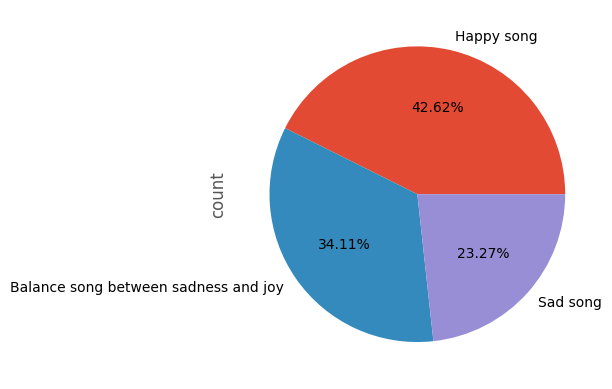

In [311]:
df['type_of_song_by_valence'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

----------------------------------

##### Extracting new column **[type_of_song_by_acousticness]** from **[acousticness]**

In [312]:
def GetTypeOfAcousticness(acousticness) :
    acousticness = float(acousticness)
    if acousticness < 0.3 :
        return 'Highly electronic song'
    elif acousticness < 0.6 :
        return 'Mix of acoustic and electronic instruments'
    else :
        return 'Mostly acoustic song'


df['type_of_song_by_acousticness'] = df['acousticness'].apply(lambda x : GetTypeOfAcousticness(x))

In [313]:
df['type_of_song_by_acousticness'].unique()

array(['Mostly acoustic song',
       'Mix of acoustic and electronic instruments',
       'Highly electronic song'], dtype=object)

In [314]:
df[['acousticness','type_of_song_by_acousticness']]

,acousticness,type_of_song_by_acousticness
0,0.98200,Mostly acoustic song
1,0.73200,Mostly acoustic song
2,0.96100,Mostly acoustic song
3,0.96700,Mostly acoustic song
4,0.95700,Mostly acoustic song
...,...,...
170648,0.08460,Highly electronic song
170649,0.20600,Highly electronic song
170650,0.10100,Highly electronic song
170651,0.00998,Highly electronic song


In [315]:
df['type_of_song_by_acousticness'].value_counts()

type_of_song_by_acousticness
Mostly acoustic song                          78239
Highly electronic song                        66554
Mix of acoustic and electronic instruments    25860
Name: count, dtype: int64

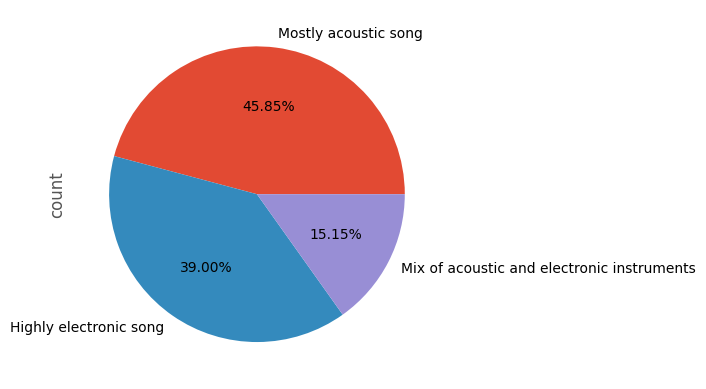

In [316]:
df['type_of_song_by_acousticness'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

---------------------------------

##### Extracting new column **[type_of_song_by_danceability]** from **[danceability]**

In [317]:
def GetTypeOfDanceability(danceability) :
    danceability = float(danceability)
    if danceability < 0.4 :
        return 'Not suitable for dance'
    elif danceability < 0.7 :
        return 'Medium-paced song'
    else :
        return 'Highly danceable song'

df['type_of_song_by_danceability'] = df['danceability'].apply( lambda x : GetTypeOfDanceability(x))

In [318]:
df['type_of_song_by_danceability'].unique()

array(['Not suitable for dance', 'Highly danceable song',
       'Medium-paced song'], dtype=object)

In [319]:
df[['danceability','type_of_song_by_danceability']]

,danceability,type_of_song_by_danceability
0,0.279,Not suitable for dance
1,0.819,Highly danceable song
2,0.328,Not suitable for dance
3,0.275,Not suitable for dance
4,0.418,Medium-paced song
...,...,...
170648,0.786,Highly danceable song
170649,0.717,Highly danceable song
170650,0.634,Medium-paced song
170651,0.671,Medium-paced song


In [320]:
df['type_of_song_by_danceability'].value_counts()

type_of_song_by_danceability
Medium-paced song         99097
Not suitable for dance    38619
Highly danceable song     32937
Name: count, dtype: int64

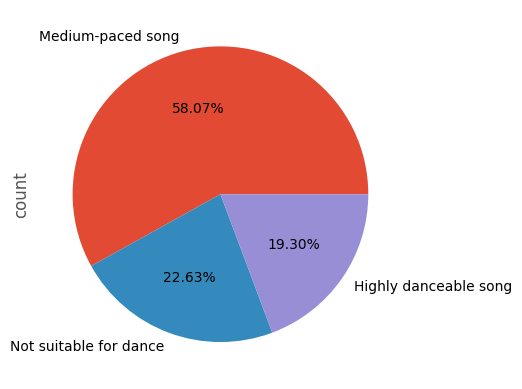

In [321]:
df['type_of_song_by_danceability'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

---------------------------------

##### Extracting new column **[Energy_Level_of_the_Song]** from **[energy]**

In [322]:
def Energy_Level_of_the_Song(energy) :
    energy = float(energy)
    if energy < 0.3 :
        return 'Slow song'
    elif energy < 0.6 :
        return 'Medium-energy song'
    else :
        return 'High-energy song (Enthusiastic)'

df['Energy_Level_of_the_Song'] = df['energy'].apply( lambda x : Energy_Level_of_the_Song(x))

In [323]:
df['Energy_Level_of_the_Song'].unique()

array(['Slow song', 'Medium-energy song',
       'High-energy song (Enthusiastic)'], dtype=object)

In [324]:
df[['energy','Energy_Level_of_the_Song']]

,energy,Energy_Level_of_the_Song
0,0.211,Slow song
1,0.341,Medium-energy song
2,0.166,Slow song
3,0.309,Medium-energy song
4,0.193,Slow song
...,...,...
170648,0.808,High-energy song (Enthusiastic)
170649,0.753,High-energy song (Enthusiastic)
170650,0.858,High-energy song (Enthusiastic)
170651,0.623,High-energy song (Enthusiastic)


In [325]:
df['Energy_Level_of_the_Song'].value_counts()

Energy_Level_of_the_Song
High-energy song (Enthusiastic)    61083
Medium-energy song                 57557
Slow song                          52013
Name: count, dtype: int64

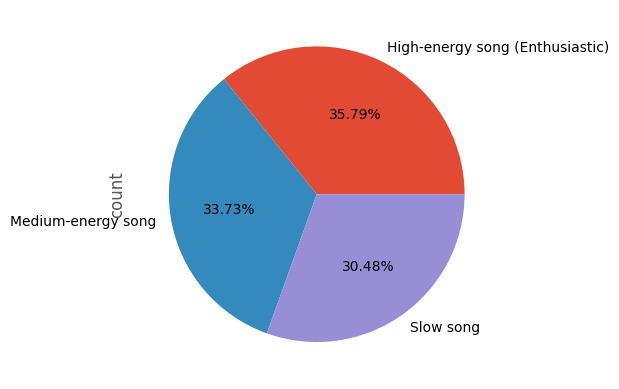

In [326]:
df['Energy_Level_of_the_Song'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

----------------------------

##### Extracting new column **[type_of_song_by_instrumentalness]** from **[instrumentalness]**

In [327]:
def type_of_song_by_instrumentalness(instrumentalness) :
    instrumentalness = float(instrumentalness)
    if instrumentalness < 0.3 :
        return 'Song clearly contains lyrics'
    elif instrumentalness < 0.7 :
        return 'Song contain some words'
    else:
        return 'Nearly purely instrumental song'

df['type_of_song_by_instrumentalness'] = df['instrumentalness'].apply( lambda x : type_of_song_by_instrumentalness(x))

In [328]:
df['type_of_song_by_instrumentalness'].unique()

array(['Nearly purely instrumental song', 'Song clearly contains lyrics',
       'Song contain some words'], dtype=object)

In [329]:
df[['instrumentalness','type_of_song_by_instrumentalness']]

,instrumentalness,type_of_song_by_instrumentalness
0,0.878000,Nearly purely instrumental song
1,0.000000,Song clearly contains lyrics
2,0.913000,Nearly purely instrumental song
3,0.000028,Song clearly contains lyrics
4,0.000002,Song clearly contains lyrics
...,...,...
170648,0.000289,Song clearly contains lyrics
170649,0.000000,Song clearly contains lyrics
170650,0.000009,Song clearly contains lyrics
170651,0.000008,Song clearly contains lyrics


In [330]:
df['type_of_song_by_instrumentalness'].value_counts()

type_of_song_by_instrumentalness
Song clearly contains lyrics       135868
Nearly purely instrumental song     24206
Song contain some words             10579
Name: count, dtype: int64

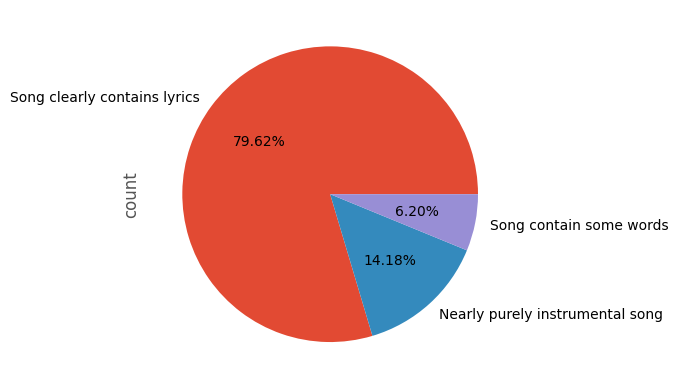

In [331]:
df['type_of_song_by_instrumentalness'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

------------------------

##### Extracting new column **[type_of_song_by_liveness]** from **[liveness]**

In [332]:
def type_of_song_by_liveness(liveness):
    liveness = float(liveness)
    if liveness < 0.3 :
        return 'Pure studio recordings'
    elif liveness < 0.7 :
        return 'Records may have a simple reaction with the audience'
    else:
        return 'Clearly a live recording with an audience'

df['type_of_song_by_liveness'] = df['liveness'].apply( lambda x : type_of_song_by_liveness(x))

In [333]:
df['type_of_song_by_liveness'].unique()

array(['Records may have a simple reaction with the audience',
       'Pure studio recordings',
       'Clearly a live recording with an audience'], dtype=object)

In [334]:
df[['liveness','type_of_song_by_liveness']]

,liveness,type_of_song_by_liveness
0,0.6650,Records may have a simple reaction with the au...
1,0.1600,Pure studio recordings
2,0.1010,Pure studio recordings
3,0.3810,Records may have a simple reaction with the au...
4,0.2290,Pure studio recordings
...,...,...
170648,0.0822,Pure studio recordings
170649,0.1010,Pure studio recordings
170650,0.2580,Pure studio recordings
170651,0.6430,Records may have a simple reaction with the au...


In [335]:
df['type_of_song_by_liveness'].value_counts()

type_of_song_by_liveness
Pure studio recordings                                  135703
Records may have a simple reaction with the audience     29446
Clearly a live recording with an audience                 5504
Name: count, dtype: int64

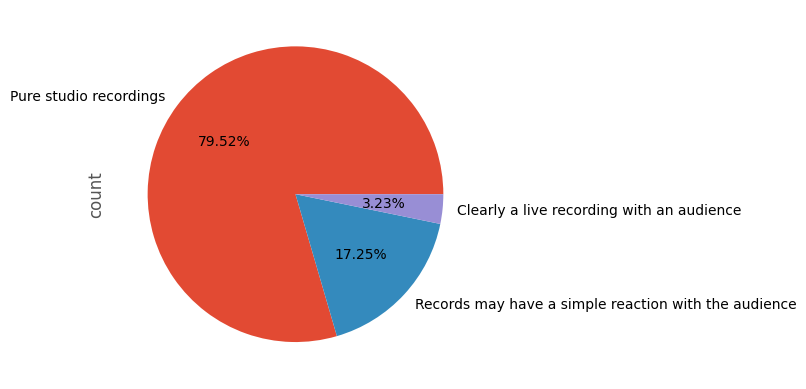

In [336]:
df['type_of_song_by_liveness'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

----------------------

##### Extracting new column **[type_of_song_by_loudness(dB)]** from **[loudness]**

In [337]:
def type_of_song_by_loudness(loudness) :
    loudness = float(loudness)
    if loudness <= -30 :
        return 'Quieter Sound'
    elif loudness <= -5 :
        return 'Quiet song'
    else :
        return 'Loud song'

df['type_of_song_by_loudness(dB)'] = df['loudness'].apply(lambda x : type_of_song_by_loudness(x))

In [338]:
df['type_of_song_by_loudness(dB)'].unique()

array(['Quiet song', 'Quieter Sound', 'Loud song'], dtype=object)

In [339]:
df[['loudness','type_of_song_by_loudness(dB)']]

,loudness,type_of_song_by_loudness(dB)
0,-20.096,Quiet song
1,-12.441,Quiet song
2,-14.850,Quiet song
3,-9.316,Quiet song
4,-10.096,Quiet song
...,...,...
170648,-3.702,Loud song
170649,-6.020,Quiet song
170650,-2.226,Loud song
170651,-7.161,Quiet song


In [340]:
df['type_of_song_by_loudness(dB)'].value_counts()

type_of_song_by_loudness(dB)
Quiet song       152871
Loud song         16475
Quieter Sound      1307
Name: count, dtype: int64

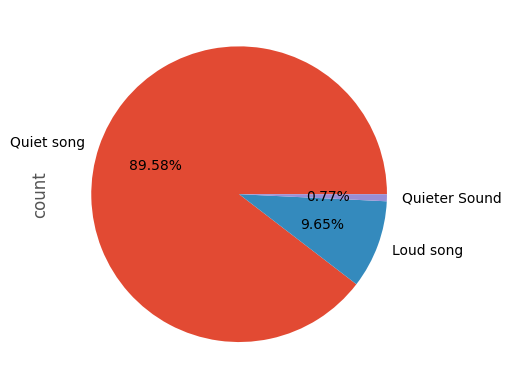

In [341]:
df['type_of_song_by_loudness(dB)'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

----------------------

##### Extracting new column **[type_of_song_by_mode]** from **[mode]**                                                                    

In [342]:
def typeOfSongByMode(mode) :
    mode = int(mode)
    if mode == 0:
        return 'Sad tone (Minor)'
    else:
        return 'Happy tone (Major)'


df['type_of_song_by_mode'] = df['mode'].apply(lambda x : typeOfSongByMode(x))

In [343]:
df['type_of_song_by_mode'].unique()

array(['Happy tone (Major)', 'Sad tone (Minor)'], dtype=object)

In [344]:
df[['mode','type_of_song_by_mode']]

,mode,type_of_song_by_mode
0,1,Happy tone (Major)
1,1,Happy tone (Major)
2,1,Happy tone (Major)
3,1,Happy tone (Major)
4,1,Happy tone (Major)
...,...,...
170648,1,Happy tone (Major)
170649,1,Happy tone (Major)
170650,0,Sad tone (Minor)
170651,1,Happy tone (Major)


In [345]:
df['type_of_song_by_mode'].value_counts()

type_of_song_by_mode
Happy tone (Major)    120635
Sad tone (Minor)       50018
Name: count, dtype: int64

C:\Users\RPC\AppData\Local\Temp\ipykernel_18560\1611046123.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type_of_song_by_mode', data=df, palette=['green','red'])


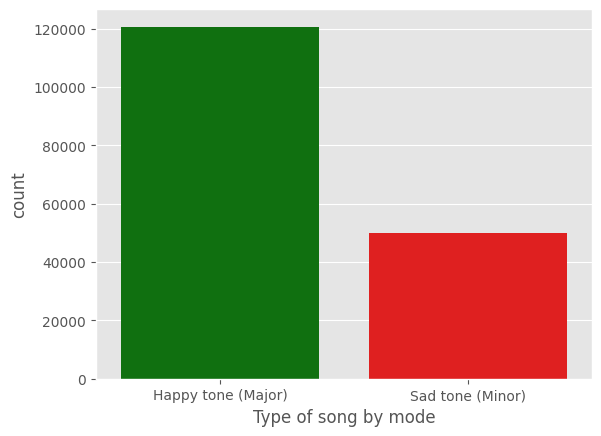

In [346]:
sns.countplot(x='type_of_song_by_mode', data=df, palette=['green','red'])
plt.xlabel('Type of song by mode')
plt.show()

-----------------

##### Extracting new column **[type_of_song_by_speechiness]** from **[speechiness]** 

In [347]:
def typeOfSongBySpeechiness(speechiness):
    speechiness = float(speechiness)
    if speechiness < 0.3 :
        return 'Mostly instrumental song'
    elif speechiness < 0.7 :
        return 'Song with some speech'
    else:
        return 'Podcasts or speech-heavy rap'

df['type_of_song_by_speechiness'] = df['speechiness'].apply(lambda x : typeOfSongBySpeechiness(x))

In [348]:
df['type_of_song_by_speechiness'].unique()

array(['Mostly instrumental song', 'Song with some speech',
       'Podcasts or speech-heavy rap'], dtype=object)

In [349]:
df[['speechiness','type_of_song_by_speechiness']]

,speechiness,type_of_song_by_speechiness
0,0.0366,Mostly instrumental song
1,0.4150,Song with some speech
2,0.0339,Mostly instrumental song
3,0.0354,Mostly instrumental song
4,0.0380,Mostly instrumental song
...,...,...
170648,0.0881,Mostly instrumental song
170649,0.0605,Mostly instrumental song
170650,0.0809,Mostly instrumental song
170651,0.3080,Song with some speech


In [350]:
df['type_of_song_by_speechiness'].value_counts()

type_of_song_by_speechiness
Mostly instrumental song        159817
Song with some speech             5966
Podcasts or speech-heavy rap      4870
Name: count, dtype: int64

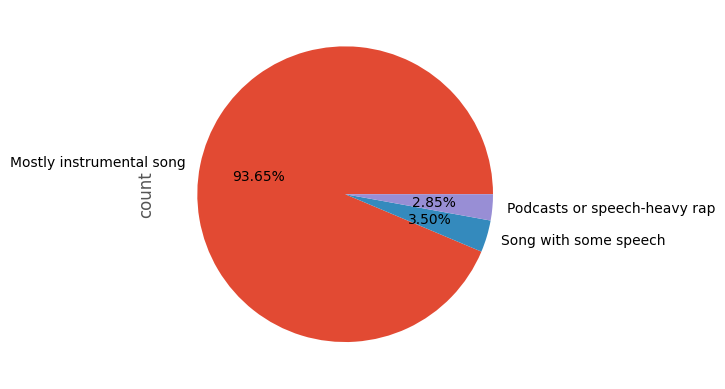

In [351]:
df['type_of_song_by_speechiness'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

----------------------

##### Extracting new column **[type_of_tempo_in_Beats_Per_Minute(BPM)]** from **[tempo]**

In [352]:
def typeOftempoInBeatsPerMinute(tempo):
    tempo = float(tempo)
    if tempo < 80.0 :
        return 'Slow song'
    elif tempo < 120.0 :
        return 'Medium-paced song'
    else:
        return 'Fast-paced song'

df['type_of_tempo_in_Beats_Per_Minute(BPM)'] = df['tempo'].apply(lambda x: typeOftempoInBeatsPerMinute(x))

In [353]:
df['type_of_tempo_in_Beats_Per_Minute(BPM)'].unique()

array(['Medium-paced song', 'Slow song', 'Fast-paced song'], dtype=object)

In [354]:
df[['tempo','type_of_tempo_in_Beats_Per_Minute(BPM)']]

,tempo,type_of_tempo_in_Beats_Per_Minute(BPM)
0,80.954,Medium-paced song
1,60.936,Slow song
2,110.339,Medium-paced song
3,100.109,Medium-paced song
4,101.665,Medium-paced song
...,...,...
170648,105.029,Medium-paced song
170649,137.936,Fast-paced song
170650,91.688,Medium-paced song
170651,75.055,Slow song


In [355]:
df['type_of_tempo_in_Beats_Per_Minute(BPM)'].value_counts()

type_of_tempo_in_Beats_Per_Minute(BPM)
Medium-paced song    78608
Fast-paced song      73959
Slow song            18086
Name: count, dtype: int64

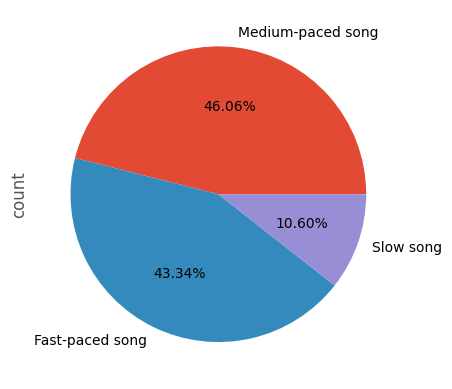

In [356]:
df['type_of_tempo_in_Beats_Per_Minute(BPM)'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

-------------------------------------------

In [357]:
dtime=datetime.now()
df['Age_of_song']=dtime.year-df['year']

In [358]:
df['Age_of_song'].max()

np.int64(105)

In [359]:
bins = [0,20,40,60,80,120]
labels = ['New','Modern','Old','Classic','Vintage']
df['Age_category'] = pd.cut(df['Age_of_song'],bins=bins, labels=labels)

In [360]:
df['Age_category'].value_counts().sort_values()

Age_category
Vintage    22779
New        29619
Classic    38674
Modern     39632
Old        39949
Name: count, dtype: int64

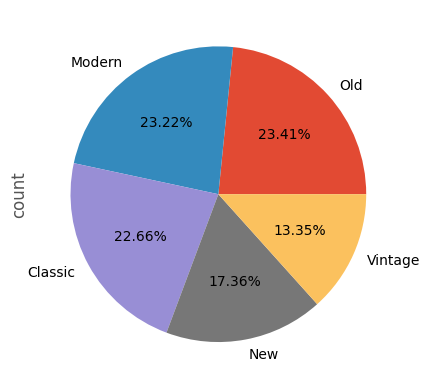

In [361]:
df['Age_category'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

--------------------------
--------------------------

In [ ]:
#df.to_excel('Music recommendation system (New data).Xlsx',index=False)

----------------------------
----------------------------
---------------------------

## **Analysis**

------------------------------

In [363]:
df

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,...,type_of_song_by_danceability,Energy_Level_of_the_Song,type_of_song_by_instrumentalness,type_of_song_by_liveness,type_of_song_by_loudness(dB),type_of_song_by_mode,type_of_song_by_speechiness,type_of_tempo_in_Beats_Per_Minute(BPM),Age_of_song,Age_category
0,0.0594,1921,0.98200,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878000,...,Not suitable for dance,Slow song,Nearly purely instrumental song,Records may have a simple reaction with the au...,Quiet song,Happy tone (Major),Mostly instrumental song,Medium-paced song,105,Vintage
1,0.9630,1921,0.73200,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000000,...,Highly danceable song,Medium-energy song,Song clearly contains lyrics,Pure studio recordings,Quiet song,Happy tone (Major),Song with some speech,Slow song,105,Vintage
2,0.0394,1921,0.96100,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913000,...,Not suitable for dance,Slow song,Nearly purely instrumental song,Pure studio recordings,Quiet song,Happy tone (Major),Mostly instrumental song,Medium-paced song,105,Vintage
3,0.1650,1921,0.96700,['Frank Parker'],0.275,210000,0.309,0,3ftBPsC5vPBKxYSee08FDH,0.000028,...,Not suitable for dance,Medium-energy song,Song clearly contains lyrics,Records may have a simple reaction with the au...,Quiet song,Happy tone (Major),Mostly instrumental song,Medium-paced song,105,Vintage
4,0.2530,1921,0.95700,['Phil Regan'],0.418,166693,0.193,0,4d6HGyGT8e121BsdKmw9v6,0.000002,...,Medium-paced song,Slow song,Song clearly contains lyrics,Pure studio recordings,Quiet song,Happy tone (Major),Mostly instrumental song,Medium-paced song,105,Vintage
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170648,0.6080,2020,0.08460,"['Anuel AA', 'Daddy Yankee', 'KAROL G', 'Ozuna...",0.786,301714,0.808,0,0KkIkfsLEJbrcIhYsCL7L5,0.000289,...,Highly danceable song,High-energy song (Enthusiastic),Song clearly contains lyrics,Pure studio recordings,Loud song,Happy tone (Major),Mostly instrumental song,Medium-paced song,6,New
170649,0.7340,2020,0.20600,['Ashnikko'],0.717,150654,0.753,0,0OStKKAuXlxA0fMH54Qs6E,0.000000,...,Highly danceable song,High-energy song (Enthusiastic),Song clearly contains lyrics,Pure studio recordings,Quiet song,Happy tone (Major),Mostly instrumental song,Fast-paced song,6,New
170650,0.6370,2020,0.10100,['MAMAMOO'],0.634,211280,0.858,0,4BZXVFYCb76Q0Klojq4piV,0.000009,...,Medium-paced song,High-energy song (Enthusiastic),Song clearly contains lyrics,Pure studio recordings,Loud song,Sad tone (Minor),Mostly instrumental song,Medium-paced song,6,New
170651,0.1950,2020,0.00998,['Eminem'],0.671,337147,0.623,1,5SiZJoLXp3WOl3J4C8IK0d,0.000008,...,Medium-paced song,High-energy song (Enthusiastic),Song clearly contains lyrics,Records may have a simple reaction with the au...,Quiet song,Happy tone (Major),Song with some speech,Slow song,6,New


In [364]:
df.shape

(170653, 32)

In [365]:
df.columns

Index(['valence', 'year', 'acousticness', 'artists', 'danceability',
       'duration_ms', 'energy', 'explicit', 'id', 'instrumentalness', 'key',
       'liveness', 'loudness', 'mode', 'name', 'popularity', 'release_date',
       'speechiness', 'tempo', 'duration_min', 'type_of_song_by_valence',
       'type_of_song_by_acousticness', 'type_of_song_by_danceability',
       'Energy_Level_of_the_Song', 'type_of_song_by_instrumentalness',
       'type_of_song_by_liveness', 'type_of_song_by_loudness(dB)',
       'type_of_song_by_mode', 'type_of_song_by_speechiness',
       'type_of_tempo_in_Beats_Per_Minute(BPM)', 'Age_of_song',
       'Age_category'],
      dtype='object')

-------------------------------

- ##### **Box Plot On popularity Across type of song by valence**

C:\Users\RPC\AppData\Local\Temp\ipykernel_18560\2409569242.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,y="popularity",x="type_of_song_by_valence",orient="v",ax=axes, palette=['r','b','g'])


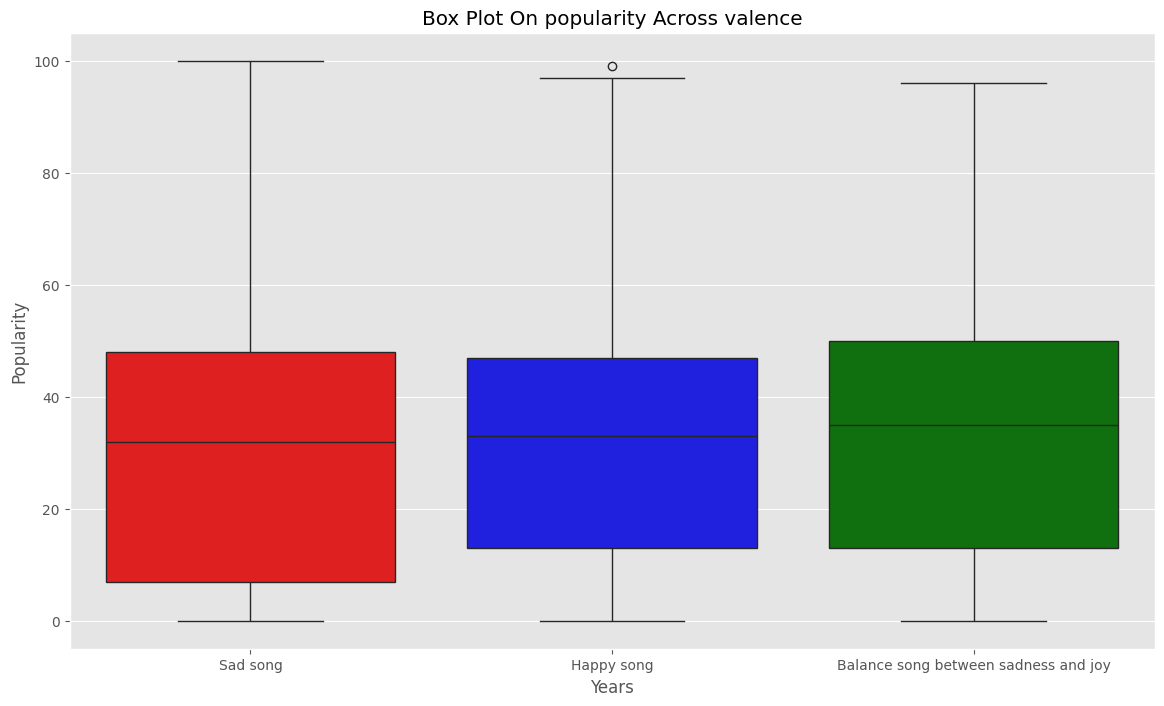

In [366]:
fig, axes = plt.subplots(nrows=1,ncols=1)
fig.set_size_inches(14, 8)
sns.boxplot(data=df,y="popularity",x="type_of_song_by_valence",orient="v",ax=axes, palette=['r','b','g'])
axes.set(xlabel='Years', ylabel='Popularity',title="Box Plot On popularity Across valence")
plt.show()

#### This is a box plot visualizing the distribution of 'popularity' across three categories of songs based on their perceived 'valence': "Sad song", "Happy song", and "Balance song between sadness and joy". While the x-axis label says "Years", the actual categories represent different emotional tones or valence levels of the songs.

#### **Sad song** :

- ##### **The Box (Interquartile Range - IQR)**: The middle 50% of popularity scores for sad songs falls roughly between a popularity of 7 and 48.
- ##### **The Median (Q2)**: The line inside the box indicates a median popularity of around 30-32.
- ##### **The Whiskers**: The whiskers extend from a low of around 0 to a high of 100, indicating a wide range of popularity for sad songs, including some very unpopular and some very popular ones.
- ##### **Outliers**: There don't appear to be any distinct outliers marked beyond the whiskers.

#### **Happy song** :

- ##### **The Box (Interquartile Range - IQR)**: The middle 50% of popularity scores for happy songs falls roughly between a popularity of 14 and 47.
- ##### **The Median (Q2)**: The line inside the box indicates a median popularity of around 30-32, similar to sad songs.
- ##### **The Whiskers**: The whiskers extend from a low of around 0 to a high of just below 100, again showing a wide range of popularity.
- ##### **Outliers**: There is one potential outlier with a popularity score close to 98.

#### **Balance song between sadness and joy** :

- ##### **The Box (Interquartile Range - IQR)**: The middle 50% of popularity scores for these balanced songs falls roughly between a popularity of 12 and 50. This is a slightly wider IQR compared to the other two categories.
- ##### **The Median (Q2)**: The line inside the box indicates a median popularity of around 35, slightly higher than both sad and happy songs.
- ##### **The Whiskers**: The whiskers extend from a low of around 0 to a high of around 95, showing a wide range of popularity, similar to the other categories.
- ##### **Outliers**: There don't appear to be any distinct outliers marked beyond the whiskers.

#### **Overall Observations** :

- ##### **Similar Median Popularity**: The median popularity across all three categories is relatively similar, hovering around the 30-35 range. This suggests that, on average, the perceived valence (sad, happy, balanced) doesn't drastically impact the popularity of a song in this dataset.
- ##### **Wide Range of Popularity**: All three categories exhibit a wide range of popularity scores, from very low (close to 0) to very high (close to or at 100). This indicates that within each emotional tone, there are both popular and unpopular songs.
- ##### **Slightly Higher Median for Balanced Songs**: Songs perceived as balanced between sadness and joy show a slightly higher median popularity compared to purely sad or happy songs. However, this difference isn't substantial.
- ##### **Outlier in Happy Songs**: There's a single potential high outlier in the "Happy song" category.

---------------------------

- ##### **Analyze popularity distribution**

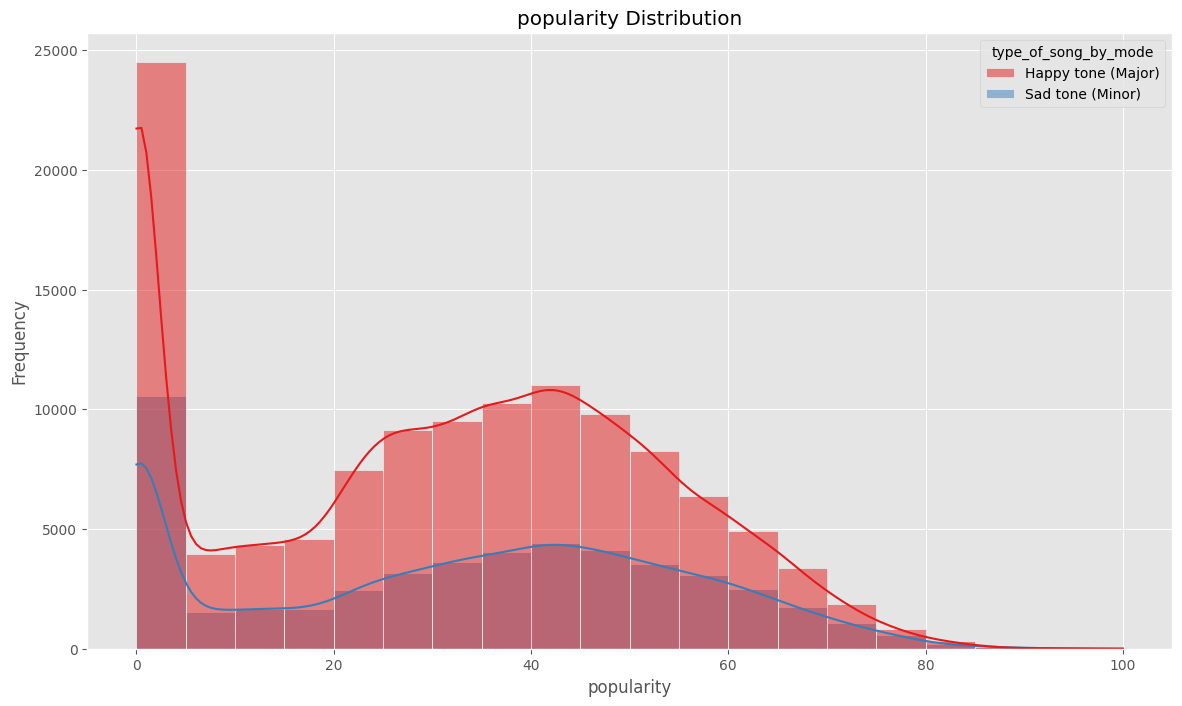

In [367]:
plt.figure(figsize=(14, 8))
sns.histplot(data=df, x='popularity', hue='type_of_song_by_mode', kde=True, bins=20, palette='Set1')
plt.title('popularity Distribution')
plt.xlabel('popularity')
plt.ylabel('Frequency')
plt.show()

#### This is a histogram overlaid with a Kernel Density Estimate (KDE) plot, visualizing the distribution of the 'popularity' of songs, separated by their musical 'mode': Happy tone (Major) and Sad tone (Minor).

#### **Overall Popularity Distribution (considering both modes)**:

- ##### **Bimodal Distribution**: The overall distribution of popularity (if we were to look at the combined bars and lines) appears to be bimodal, with one significant peak at very low popularity scores (around 0-5) and another broader peak in the moderate popularity range (around 30-50). This suggests that there are many very unpopular songs and a significant number of songs with moderate popularity, but fewer songs with extremely high popularity.

#### **Popularity Distribution by Mode**:

#### **Happy Tone (Major - Red)**:

- ##### **Lower Popularity Peak** : Shows a very high frequency of songs with extremely low popularity scores (around 0-5).
- ##### **Moderate Popularity Peak** : Also shows a significant peak in the moderate popularity range (around 30-60), with the highest frequency around 40-50.
- ##### **Right Skew** : The distribution is skewed to the right, indicating a longer tail towards higher popularity scores, although the frequency decreases significantly beyond the moderate peak.

#### **Sad Tone (Minor - Blue)**:

- ##### **Lower Popularity Peak**: Similar to happy tones, there's a peak at very low popularity scores (around 0-5), although the frequency is lower than for happy tones in this range.
- ##### **Moderate Popularity Peak**: Shows a broader peak in the moderate popularity range (around 30-50), with the highest frequency appearing slightly lower than for happy tones in this range (around 30-40).
- ##### ** More Even Distribution in Moderate Range**: The distribution in the moderate popularity range seems somewhat more spread out compared to happy tones.
- ##### **Faster Decline at Higher Popularity**: The frequency of sad tone songs appears to decline more rapidly at higher popularity scores compared to happy tone songs.

#### **Key Observations**:

- ##### **Both Happy and Sad Tone Songs Have a Large Number of Very Unpopular Tracks**: The prominent peak at the very low end of the popularity spectrum is present for both modes, suggesting a significant number of less-listened-to songs regardless of their major or minor key.
- ##### **Happy Tone Songs Tend to Have a Slightly Higher Frequency in the Moderate to Higher Popularity Range**: The red bars and line (Happy tone) are generally higher than the blue bars and line (Sad tone) in the moderate to somewhat higher popularity regions, suggesting that happy tone songs might, on average, achieve slightly higher popularity in this dataset.
- ##### **Sad Tone Songs Show a More Spread-Out Popularity in the Moderate Range**: The blue distribution is broader in the moderate popularity range, indicating a wider variety of popularity levels among sad tone songs compared to the more concentrated peak for happy tone songs.
- ##### **Very High Popularity is Rare for Both Modes**: The frequency of songs with very high popularity scores (above 80) is very low for both happy and sad tones.

---------------------------

- ##### **Investigate relationships between type_of_song_by_valence and type_of_song_by_danceability**

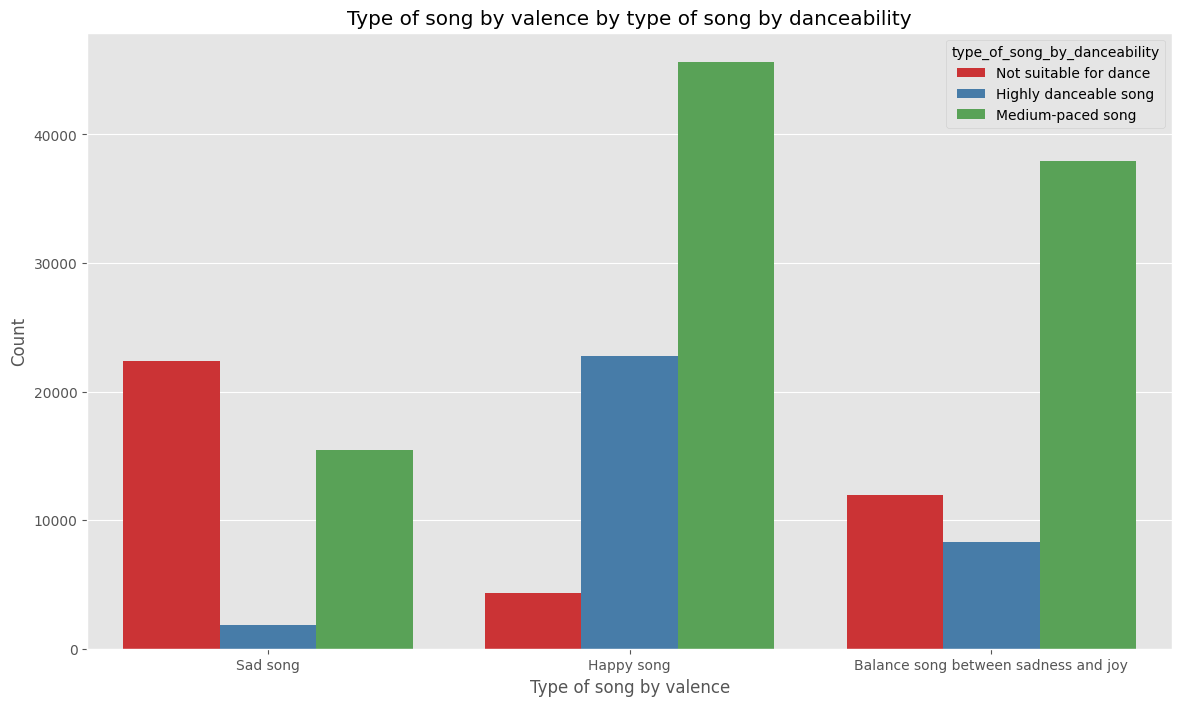

In [368]:
plt.figure(figsize=(14, 8))
sns.countplot(data=df, x='type_of_song_by_valence', hue='type_of_song_by_danceability', palette='Set1')
plt.title('Type of song by valence by type of song by danceability')
plt.xlabel('Type of song by valence')
plt.ylabel('Count')
plt.show()

#### This is a grouped bar chart visualizing the count of songs across different categories of 'type of song by valence' (Sad song, Happy song, Balance song between sadness and joy), further segmented by 'type of song by danceability' (Not suitable for dance, Highly danceable song, Medium-paced song).

#### **Sad Song** :

- ##### The largest count of sad songs falls into the "Not suitable for dance" category (light blue bar), with over 22,500 songs.
- ##### There's a smaller count of "Medium-paced songs" (light red bar), with around 15,000 songs.
- ##### The count of "Highly danceable songs" (grey bar) is the lowest among sad songs, with just over 2,500 songs.

#### **Happy Song**:

- ##### The largest count of happy songs falls into the "Highly danceable song" category (grey bar), with over 23,000 songs.
- ##### There's a significant count of "Medium-paced songs" (light red bar), with the highest count across all valence categories at over 45,000 songs.
- ##### The count of "Not suitable for dance" happy songs (light blue bar) is the lowest among happy songs, with just over 4,000 songs.

#### **Balance song between sadness and joy**:

- ##### he largest count of balanced songs falls into the "Medium-paced song" category (light red bar), with around 38,000 songs.
- ##### There's a notable count of "Not suitable for dance" balanced songs (light blue bar), with around 12,000 songs.
- ##### The count of "Highly danceable songs" (grey bar) is the lowest among balanced songs, with just over 3,000 songs.

#### **Overall Observations**:

- ##### Sad songs are predominantly categorized as "Not suitable for dance".
- ##### Happy songs have the highest representation in the "Highly danceable song" category, but an even larger number are "Medium-paced songs".
- ##### Balanced songs are most frequently "Medium-paced songs".
- ##### The "Medium-paced song" category has the highest overall count of songs across all valence types.
- ##### The "Highly danceable song" category has a relatively high count for happy songs but lower counts for sad and balanced songs.
- ##### The "Not suitable for dance" category has a high count for sad songs but lower counts for happy and balanced songs.

-----------------------------

- ##### **Investigate relationships between Type of song by acousticness and Type of song by instrumentalness**

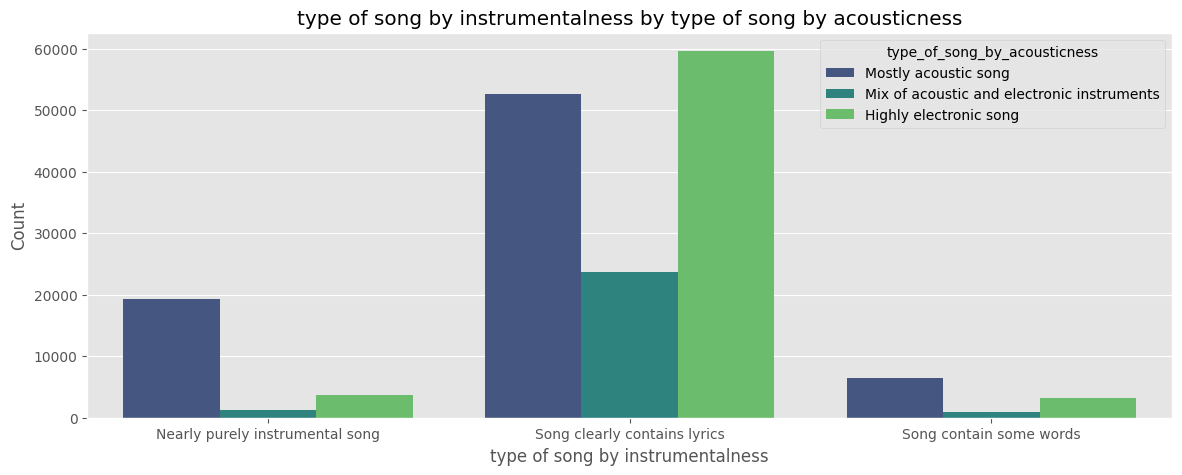

In [369]:
plt.figure(figsize=(14, 5))
sns.countplot(data=df, x='type_of_song_by_instrumentalness', hue='type_of_song_by_acousticness', palette='viridis')
plt.title('type of song by instrumentalness by type of song by acousticness')
plt.xlabel('type of song by instrumentalness')
# xticks(rotation=45)
plt.ylabel('Count')
plt.show()

#### This is a grouped bar chart visualizing the count of songs across different categories of 'type of song by instrumentalness', further segmented by 'type of song by acousticness'.

#### **Nearly purely instrumental song:**

- ##### **Mostly acoustic song** : Approximately 19,000
- ##### **Mix of acoustic and electronic instruments** : Just over 1,000
- ##### **Highly electronic song** : Around 3,000

#### **Song clearly contains lyrics:**

- ##### **Mostly acoustic song** : Approximately 52,000
- ##### **Mix of acoustic and electronic instruments **: Around 23,500
- ##### **Highly electronic song** : Approximately 59,000

#### **Song contain some words:**

- ##### **Mostly acoustic song** : Around 6,000
- ##### **Mix of acoustic and electronic instruments** : Just under 1,000
- ##### **Highly electronic song** : Around 3,000

#### **Overall Observations:**

- ##### The "Song clearly contains lyrics" category has the highest overall count of songs across all acousticness types.
- ##### For songs that are "nearly purely instrumental", the vast majority are categorized as "Mostly acoustic songs". The counts for mixed and highly electronic instrumental songs are much lower.
- ##### For songs that "clearly contain lyrics", there are substantial numbers in all three acousticness categories, with "Highly electronic song" having the highest count, followed closely by "Mostly acoustic song". Songs with a "Mix of acoustic and electronic instruments" also have a significant presence.
- ##### Songs that "contain some words" have relatively low counts across all acousticness types, with "Mostly acoustic song" having the highest count in this instrumentalness category.
- ##### "Highly electronic songs" are most prevalent in the "Song clearly contains lyrics" category.
- ##### The "Mix of acoustic and electronic instruments" category generally has lower counts compared to the other two acousticness types within each instrumentalness category.

-----------------------------

- ##### **Songs with popularity >= 95**

In [370]:
Popul_GreaterEqual_95 = df.loc[(df["popularity"] >= 95) , (["name","artists","year","popularity","type_of_song_by_valence"])]
Popul_GreaterEqual_95

,name,artists,year,popularity,type_of_song_by_valence
19606,Mood (feat. iann dior),"['24kGoldn', 'iann dior']",2020,99,Happy song
19607,For The Night (feat. Lil Baby & DaBaby),"['Pop Smoke', 'Lil Baby', 'DaBaby']",2020,95,Balance song between sadness and joy
19608,WAP (feat. Megan Thee Stallion),"['Cardi B', 'Megan Thee Stallion']",2020,96,Balance song between sadness and joy
19610,positions,['Ariana Grande'],2020,96,Happy song
19611,Dakiti,"['Bad Bunny', 'Jhay Cortez']",2020,100,Sad song
19612,What You Know Bout Love,['Pop Smoke'],2020,96,Balance song between sadness and joy
19615,Holy (feat. Chance The Rapper),"['Justin Bieber', 'Chance the Rapper']",2020,95,Balance song between sadness and joy
19616,Blinding Lights,['The Weeknd'],2020,96,Balance song between sadness and joy
19618,Dynamite,['BTS'],2020,97,Happy song
19620,Lonely (with benny blanco),"['Justin Bieber', 'benny blanco']",2020,95,Sad song


In [371]:
Popul_GreaterEqual_95['type_of_song_by_valence'].value_counts()

type_of_song_by_valence
Balance song between sadness and joy    5
Happy song                              3
Sad song                                3
Name: count, dtype: int64

- ##### **For type of song by valence** = Balance song between sadness and joy

In [372]:
Popul_GreaterEqual_95.loc[(Popul_GreaterEqual_95['type_of_song_by_valence'] == 'Balance song between sadness and joy'), (['name', 'artists','popularity','year'])]

,name,artists,popularity,year
19607,For The Night (feat. Lil Baby & DaBaby),"['Pop Smoke', 'Lil Baby', 'DaBaby']",95,2020
19608,WAP (feat. Megan Thee Stallion),"['Cardi B', 'Megan Thee Stallion']",96,2020
19612,What You Know Bout Love,['Pop Smoke'],96,2020
19615,Holy (feat. Chance The Rapper),"['Justin Bieber', 'Chance the Rapper']",95,2020
19616,Blinding Lights,['The Weeknd'],96,2020


- ##### **For type of song by valence** = Happy song

In [373]:
Popul_GreaterEqual_95.loc[(Popul_GreaterEqual_95['type_of_song_by_valence'] == 'Happy song'), (['name', 'artists','popularity','year'])]

,name,artists,popularity,year
19606,Mood (feat. iann dior),"['24kGoldn', 'iann dior']",99,2020
19610,positions,['Ariana Grande'],96,2020
19618,Dynamite,['BTS'],97,2020


- ##### **For type of song by valence** = Sad song

In [374]:
Popul_GreaterEqual_95.loc[(Popul_GreaterEqual_95['type_of_song_by_valence'] == 'Sad song'), (['name', 'artists','popularity','year'])]

,name,artists,popularity,year
19611,Dakiti,"['Bad Bunny', 'Jhay Cortez']",100,2020
19620,Lonely (with benny blanco),"['Justin Bieber', 'benny blanco']",95,2020
19623,you broke me first,['Tate McRae'],95,2020


------------------------

- ##### **Songs with popularity >= 80 AND 2020 > year >= 2010**

In [375]:
popul_Ge80_Year_Ge2010_And_Lt2020  = df.loc[(df["popularity"] >= 80) & (df['year'] >= 2010) & (df['year'] < 2020) , (["name","artists","year","popularity","type_of_song_by_valence"])]
popul_Ge80_Year_Ge2010_And_Lt2020

,name,artists,year,popularity,type_of_song_by_valence
17606,Just the Way You Are,['Bruno Mars'],2010,81,Balance song between sadness and joy
17607,"Hey, Soul Sister",['Train'],2010,83,Happy song
17613,Love The Way You Lie,"['Eminem', 'Rihanna']",2010,82,Happy song
17614,TiK ToK,['Kesha'],2010,80,Happy song
17806,Tongue Tied,['Grouplove'],2011,82,Balance song between sadness and joy
...,...,...,...,...,...
92017,Dream Girl - Remix,"['Ir Sais', 'Rauw Alejandro']",2019,81,Balance song between sadness and joy
92022,"Alone, Pt. II","['Alan Walker', 'Ava Max']",2019,80,Happy song
108604,El Efecto,"['Rauw Alejandro', 'Chencho Corleone']",2019,81,Happy song
124658,Dance Monkey,['Tones And I'],2019,81,Balance song between sadness and joy


In [376]:
popul_Ge80_Year_Ge2010_And_Lt2020['type_of_song_by_valence'].value_counts()

type_of_song_by_valence
Balance song between sadness and joy    136
Happy song                               96
Sad song                                 88
Name: count, dtype: int64

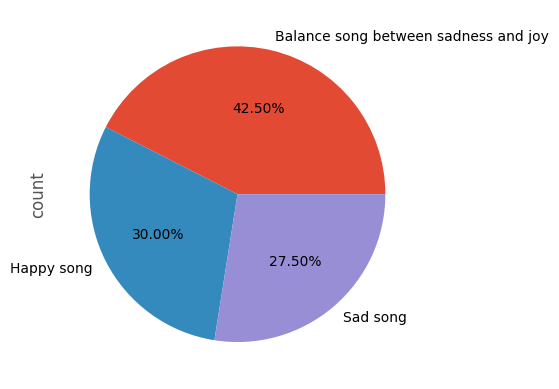

In [377]:
popul_Ge80_Year_Ge2010_And_Lt2020['type_of_song_by_valence'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

- ##### **For type of song by valence** = Balance song between sadness and joy

In [378]:
popul_Ge80_Year_Ge2010_And_Lt2020.loc[(popul_Ge80_Year_Ge2010_And_Lt2020['type_of_song_by_valence'] == 'Balance song between sadness and joy'), (['name', 'artists','popularity','year'])]

,name,artists,popularity,year
17606,Just the Way You Are,['Bruno Mars'],81,2010
17806,Tongue Tied,['Grouplove'],82,2011
18007,It's Beginning to Look a Lot like Christmas,['Michael Bublé'],83,2012
18010,When I Was Your Man,['Bruno Mars'],83,2012
18028,Just Give Me a Reason (feat. Nate Ruess),"['P!nk', 'Nate Ruess']",81,2012
...,...,...,...,...
38266,Takeaway,"['The Chainsmokers', 'ILLENIUM', 'Lennon Stella']",80,2019
57002,Psycho,['Red Velvet'],80,2019
57075,Hola - Remix,"['Dalex', 'Lenny Tavárez', 'Chencho Corleone',...",83,2019
92017,Dream Girl - Remix,"['Ir Sais', 'Rauw Alejandro']",81,2019


- ##### **For type of song by valence** = Happy song

In [379]:
popul_Ge80_Year_Ge2010_And_Lt2020.loc[(popul_Ge80_Year_Ge2010_And_Lt2020['type_of_song_by_valence'] == 'Happy song'), (['name', 'artists','popularity','year'])]

,name,artists,popularity,year
17607,"Hey, Soul Sister",['Train'],83,2010
17613,Love The Way You Lie,"['Eminem', 'Rihanna']",82,2010
17614,TiK ToK,['Kesha'],80,2010
17807,Pumped Up Kicks,['Foster The People'],84,2011
17810,Mistletoe,['Justin Bieber'],81,2011
...,...,...,...,...
57145,Jangueo,"['Alex Rose', 'Rafa Pabön']",83,2019
74952,El Efecto - Remix,"['Rauw Alejandro', 'Chencho Corleone', 'KEVVO'...",82,2019
91808,Te Vi,"['Piso 21', 'Micro TDH']",80,2018
92022,"Alone, Pt. II","['Alan Walker', 'Ava Max']",80,2019


- ##### **For type of song by valence** = Sad song

In [380]:
popul_Ge80_Year_Ge2010_And_Lt2020.loc[(popul_Ge80_Year_Ge2010_And_Lt2020['type_of_song_by_valence'] == 'Sad song'), (['name', 'artists','popularity','year'])]

,name,artists,popularity,year
17812,A Thousand Years,['Christina Perri'],81,2011
17835,Paradise,['Coldplay'],80,2011
18209,All I Want,['Kodaline'],83,2013
18220,Story of My Life,['One Direction'],83,2013
18410,"Or Nah (feat. The Weeknd, Wiz Khalifa & DJ Mus...","['Ty Dolla $ign', 'The Weeknd', 'Wiz Khalifa',...",80,2014
...,...,...,...,...
38269,Surrender,['Natalie Taylor'],82,2019
38409,Don't Call Me Up,['Mabel'],81,2019
56827,In My Mind,"['Dynoro', ""Gigi D'Agostino""]",82,2018
56909,Faded,['Alan Walker'],80,2018


---------------------------

- ##### **Songs with popularity > 80 AND 2010 > year >= 2000**

In [381]:
popul_Gt80_Year_Lt2010_And_Ge2000 = df.loc[(df["popularity"] >= 80) & (df['year'] >= 2000) & (df['year'] < 2010) , (["name","artists","year","popularity","type_of_song_by_valence"])]
popul_Gt80_Year_Lt2010_And_Ge2000

,name,artists,year,popularity,type_of_song_by_valence
15606,Yellow,['Coldplay'],2000,84,Sad song
15607,Ms. Jackson,['OutKast'],2000,80,Happy song
15608,In the End,['Linkin Park'],2000,84,Balance song between sadness and joy
15610,The Real Slim Shady,['Eminem'],2000,80,Happy song
15808,Last Resort,['Papa Roach'],2001,80,Happy song
15810,Chop Suey!,['System Of A Down'],2001,80,Sad song
16006,'Till I Collapse,"['Eminem', 'Nate Dogg']",2002,84,Sad song
16008,Without Me,['Eminem'],2002,83,Happy song
16009,The Scientist,['Coldplay'],2002,84,Sad song
16011,Can't Stop,['Red Hot Chili Peppers'],2002,80,Happy song


In [382]:
popul_Gt80_Year_Lt2010_And_Ge2000['type_of_song_by_valence'].value_counts()

type_of_song_by_valence
Happy song                              14
Sad song                                10
Balance song between sadness and joy    10
Name: count, dtype: int64

- ##### **For type of song by valence** = Balance song between sadness and jay

In [383]:
popul_Gt80_Year_Lt2010_And_Ge2000.loc[(popul_Gt80_Year_Lt2010_And_Ge2000['type_of_song_by_valence'] == 'Balance song between sadness and joy'), (['name', 'artists','popularity','year'])]

,name,artists,popularity,year
15608,In the End,['Linkin Park'],84,2000
16013,She Will Be Loved - Radio Mix,['Maroon 5'],80,2002
16214,Seven Nation Army,['The White Stripes'],80,2003
16407,Yeah! (feat. Lil Jon & Ludacris),"['Usher', 'Lil Jon', 'Ludacris']",82,2004
16609,How to Save a Life,['The Fray'],81,2005
17008,Stronger,['Kanye West'],81,2007
17209,Viva La Vida,['Coldplay'],80,2008
17213,Low (feat. T-Pain),"['Flo Rida', 'T-Pain']",80,2008
17221,Sex on Fire,['Kings of Leon'],80,2008
17238,Umbrella,"['Rihanna', 'JAY-Z']",81,2008


- ##### **For type of song by valence** = Happy song

In [384]:
popul_Gt80_Year_Lt2010_And_Ge2000.loc[(popul_Gt80_Year_Lt2010_And_Ge2000['type_of_song_by_valence'] == 'Happy song'), (['name', 'artists','popularity','year'])]

,name,artists,popularity,year
15607,Ms. Jackson,['OutKast'],80,2000
15610,The Real Slim Shady,['Eminem'],80,2000
15808,Last Resort,['Papa Roach'],80,2001
16008,Without Me,['Eminem'],83,2002
16011,Can't Stop,['Red Hot Chili Peppers'],80,2002
16210,Toxic,['Britney Spears'],80,2003
16408,My Boo,"['Usher', 'Alicia Keys']",80,2004
16610,Feel Good Inc.,['Gorillaz'],81,2005
16611,Hips Don't Lie (feat. Wyclef Jean),"['Shakira', 'Wyclef Jean']",83,2005
16806,Last Christmas - Remastered,['Wham!'],83,2006


- ##### **For type of song by valence** = Sad song

In [385]:
popul_Gt80_Year_Lt2010_And_Ge2000.loc[(popul_Gt80_Year_Lt2010_And_Ge2000['type_of_song_by_valence'] == 'Sad song'), (['name', 'artists','popularity','year'])]

,name,artists,popularity,year
15606,Yellow,['Coldplay'],84,2000
15810,Chop Suey!,['System Of A Down'],80,2001
16006,'Till I Collapse,"['Eminem', 'Nate Dogg']",84,2002
16009,The Scientist,['Coldplay'],84,2002
16206,Numb,['Linkin Park'],82,2003
16209,Bring Me To Life,['Evanescence'],80,2003
16421,Mr. Brightside,['The Killers'],80,2004
16606,Hey There Delilah,"[""Plain White T's""]",81,2005
16616,Fix You,['Coldplay'],82,2005
17016,No One,['Alicia Keys'],80,2007


---------------------------

- ##### **Songs with popularity >= 80 AND year < 2000**

In [386]:
popul_Ge80_YearLt2000 = df.loc[(df["popularity"] >= 80) & (df['year'] < 2000) , (["name","artists","year","popularity","type_of_song_by_valence"])]
popul_Ge80_YearLt2000

,name,artists,year,popularity,type_of_song_by_valence
7406,Let It Snow! Let It Snow! Let It Snow!,['Dean Martin'],1959,81,Happy song
8206,It's the Most Wonderful Time of the Year,['Andy Williams'],1963,83,Happy song
8207,Sleigh Ride,['The Ronettes'],1963,80,Happy song
8406,Rockin' Around The Christmas Tree,['Brenda Lee'],1964,85,Happy song
9007,Ain't No Mountain High Enough,"['Marvin Gaye', 'Tammi Terrell']",1967,80,Happy song
9406,Fortunate Son,['Creedence Clearwater Revival'],1969,81,Happy song
9407,Here Comes The Sun - Remastered 2009,['The Beatles'],1969,82,Balance song between sadness and joy
10006,"Rocket Man (I Think It's Going To Be A Long, L...",['Elton John'],1972,82,Balance song between sadness and joy
10406,Sweet Home Alabama,['Lynyrd Skynyrd'],1974,82,Happy song
10606,Landslide,['Fleetwood Mac'],1975,80,Balance song between sadness and joy


-----------------------------

- ##### **Songs with popularity >= 80 AND Type of song by danceability = Not suitable for dance**

------------------------------
-----------------------------

In [387]:
df = df.drop(['id','artists','name','duration_ms','release_date','year','Age_of_song'], axis=1)

In [388]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 25 columns):
 #   Column                                  Non-Null Count   Dtype   
---  ------                                  --------------   -----   
 0   valence                                 170653 non-null  float64 
 1   acousticness                            170653 non-null  float64 
 2   danceability                            170653 non-null  float64 
 3   energy                                  170653 non-null  float64 
 4   explicit                                170653 non-null  int64   
 5   instrumentalness                        170653 non-null  float64 
 6   key                                     170653 non-null  int64   
 7   liveness                                170653 non-null  float64 
 8   loudness                                170653 non-null  float64 
 9   mode                                    170653 non-null  int64   
 10  popularity                      

-----------------------
-----------------------
### **Selecting features for training model**
------------------------

In [389]:
selected_df = df.drop(['type_of_song_by_acousticness','Energy_Level_of_the_Song','type_of_song_by_liveness', 
                       'type_of_song_by_loudness(dB)','type_of_song_by_speechiness',
                       'type_of_tempo_in_Beats_Per_Minute(BPM)'], axis=1)

In [390]:
data_for_test = selected_df[170600:]

In [ ]:
data_for_test.to_excel('data_for_test.xlsx',index=False)

In [391]:
selected_df = selected_df[:170600]

------------------------------------
------------------------------------

### **Transform data**

------------------------------

In [392]:
selected_df['Age_category'].value_counts()

Age_category
Old        39949
Modern     39632
Classic    38674
New        29566
Vintage    22779
Name: count, dtype: int64

In [393]:
labels = {'New':1, 'Modern':2, 'Old':3,'Classic':4,'Vintage':5}
selected_df['Age_category'] = selected_df['Age_category'].map(labels)

In [394]:
selected_df['Age_category'].value_counts()

Age_category
3    39949
2    39632
4    38674
1    29566
5    22779
Name: count, dtype: int64

---------------------------------

In [395]:
selected_df['type_of_song_by_danceability'].value_counts()

type_of_song_by_danceability
Medium-paced song         99076
Not suitable for dance    38614
Highly danceable song     32910
Name: count, dtype: int64

In [396]:
labels2 = {'Not suitable for dance':1, 'Medium-paced song':2, 'Highly danceable song':3}
selected_df['type_of_song_by_danceability'] = selected_df['type_of_song_by_danceability'].map(labels2)

In [397]:
selected_df['type_of_song_by_danceability'].value_counts()

type_of_song_by_danceability
2    99076
1    38614
3    32910
Name: count, dtype: int64

---------------------------------
---------------------------------
## **Model**
---------------------------------
### **Spliting Data to train and test**
---------------------------------

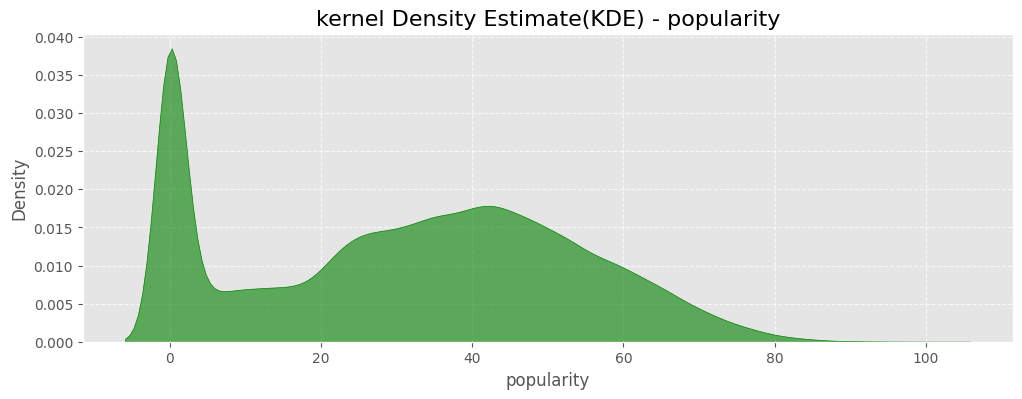

In [398]:
plt.figure(figsize=(12, 4))
sns.kdeplot(df['popularity'], fill = True, color = 'green', alpha = 0.6)
plt.title('kernel Density Estimate(KDE) - popularity', fontsize=16)
plt.xlabel('popularity', fontsize = 12)
plt.ylabel('Density', fontsize = 12)
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.show()

In [399]:
x = selected_df.drop('popularity',axis=1)
y = selected_df['popularity']

In [401]:
lb = LabelEncoder()
lb_cols = ['type_of_song_by_valence', 'type_of_song_by_instrumentalness']
for col in lb_cols:
    x[col] = lb.fit_transform(x[col])

In [406]:
import pickle
with open('label_encoders.pkl','wb') as f:
     pickle.dump(lb, f)

In [407]:
x_train,x_val,y_train,y_val=train_test_split(x,y,train_size=0.85,random_state=1234)
print(f'shape of x_train : {x_train.shape}')
print(f'shape of x_val : {x_val.shape}')
print('-------------------------------')
print(f'shape of y_train : {y_train.shape}')
print(f'shape of y_val : {y_val.shape}')

shape of x_train : (145010, 18)
shape of x_val : (25590, 18)
-------------------------------
shape of y_train : (145010,)
shape of y_val : (25590,)


-------------------------------------------
-------------------------------------------

## **Creating pipeline for model**

------------------------

In [408]:
GradientBoostingRegressor_model = GradientBoostingRegressor()
XGBRegressor_model	= XGBRegressor()
RandomForestRegressor_model	= RandomForestRegressor()

In [409]:
num_cols = ['valence', 'acousticness', 'danceability', 'energy', 'explicit',
           'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
           'speechiness', 'tempo', 'duration_min', 'type_of_song_by_danceability']

ohe_cols = ['type_of_song_by_mode']

numerical_transformer = Pipeline(steps=[('scaler', StandardScaler())])
ohe_transformer = Pipeline(steps=[('ohe', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_cols),
        ('ohe', ohe_transformer, ohe_cols)
    ])

gb_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('GradientBoostingRegressor_model', GradientBoostingRegressor()) ])

xgb_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('XGBRegressor_model', XGBRegressor()) ])

RF_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('RandomForestRegressor_model', RandomForestRegressor()) ])

In [410]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['valence', 'acousticness', 'danceability',
                                  'energy', 'explicit', 'instrumentalness',
                                  'key', 'liveness', 'loudness', 'mode',
                                  'speechiness', 'tempo', 'duration_min',
                                  'type_of_song_by_danceability']),
                                ('ohe',
                                 Pipeline(steps=[('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['type_of_song_by_mode'])])

In [ ]:
with open('One_Hot_Encoder.pkl', 'wb') as f:
     pickle.dump(ohe, f)

In [411]:
r_2=[]
rmse=[]
mae=[]

def Regression_func(model_pipeline):
    model_pipeline.fit(x_train, y_train)
    pred = model_pipeline.predict(x_val)

    R2 = r2_score(y_val, pred)
    RMSE = np.sqrt(mean_squared_error(y_val, pred))
    MAE = mean_absolute_error(y_val, pred)

    r_2.append(R2)
    rmse.append(RMSE)
    mae.append(MAE)

In [412]:
Regression_func(gb_model_pipeline)

In [413]:
Regression_func(xgb_model_pipeline)

In [414]:
Regression_func(RF_model_pipeline)

KeyboardInterrupt: 

In [415]:
Algorithms	= ['GradientBoostingRegressor', 'XGBRegressor']

In [416]:
result=pd.DataFrame({'Algorithms':Algorithms,'R2':r_2,'rmse':rmse,'mae':mae})
result

,Algorithms,R2,rmse,mae
0,GradientBoostingRegressor,0.563940,14.370905,11.095553
1,XGBRegressor,0.595485,13.841341,10.552870


### **1. R2 (R-squared):**

- ##### XGBRegressor has the highest R2 value at approximately 0.8100. This indicates that it explains about 81% of the variance in the dependent variable, which is excellent.
- ##### GradientBoostingRegressor is close behind with an R2 of approximately 0.7987, explaining about 79.87% of the variance.
- ##### DecisionTreeRegressor performs significantly worse with an R2 of approximately 0.6145. This suggests it's not as good at capturing the underlying patterns in the data.
#### **Interpretation of R2:** A higher R2 value is generally better, as it means the model can explain more of the variability in the target variable.

### **2. RMSE (Root Mean Squared Error):**

- ##### XGBRegressor has the lowest RMSE at approximately 9.4946.
- ##### GradientBoostingRegressor has a slightly higher RMSE of approximately 9.7737.
- ##### DecisionTreeRegressor has the highest RMSE at approximately 13.5255.
#### **Interpretation of RMSE:** RMSE measures the average magnitude of the errors. A lower RMSE indicates that the model's predictions are closer to the actual values.

### **3. MAE (Mean Absolute Error):**

- ##### XGBRegressor has the lowest MAE at approximately 6.7185.
- ##### GradientBoostingRegressor has a slightly higher MAE of approximately 6.8719.
- ##### DecisionTreeRegressor has the highest MAE at approximately 9.1630.
#### **Interpretation of MAE:** MAE measures the average absolute difference between the predicted and actual values. Like RMSE, a lower MAE is preferable, as it means the predictions are, on average, closer to the true values. MAE is less sensitive to outliers than RMSE.

#### **Overall Conclusion:**

- ##### Based on all three metrics (R2, RMSE, and MAE), XGBRegressor is the best-performing algorithm among the three. It exhibits the highest R2 and the lowest RMSE and MAE, indicating that it provides the most accurate and reliable predictions for this particular dataset.

- ##### GradientBoostingRegressor is a close second, performing quite well but slightly less effectively than XGBRegressor.

- ##### DecisionTreeRegressor is the weakest performer, suggesting it might be overfitting or not capturing the complexity of the data as effectively as the ensemble methods (GradientBoostingRegressor and XGBRegressor).

--------------------------

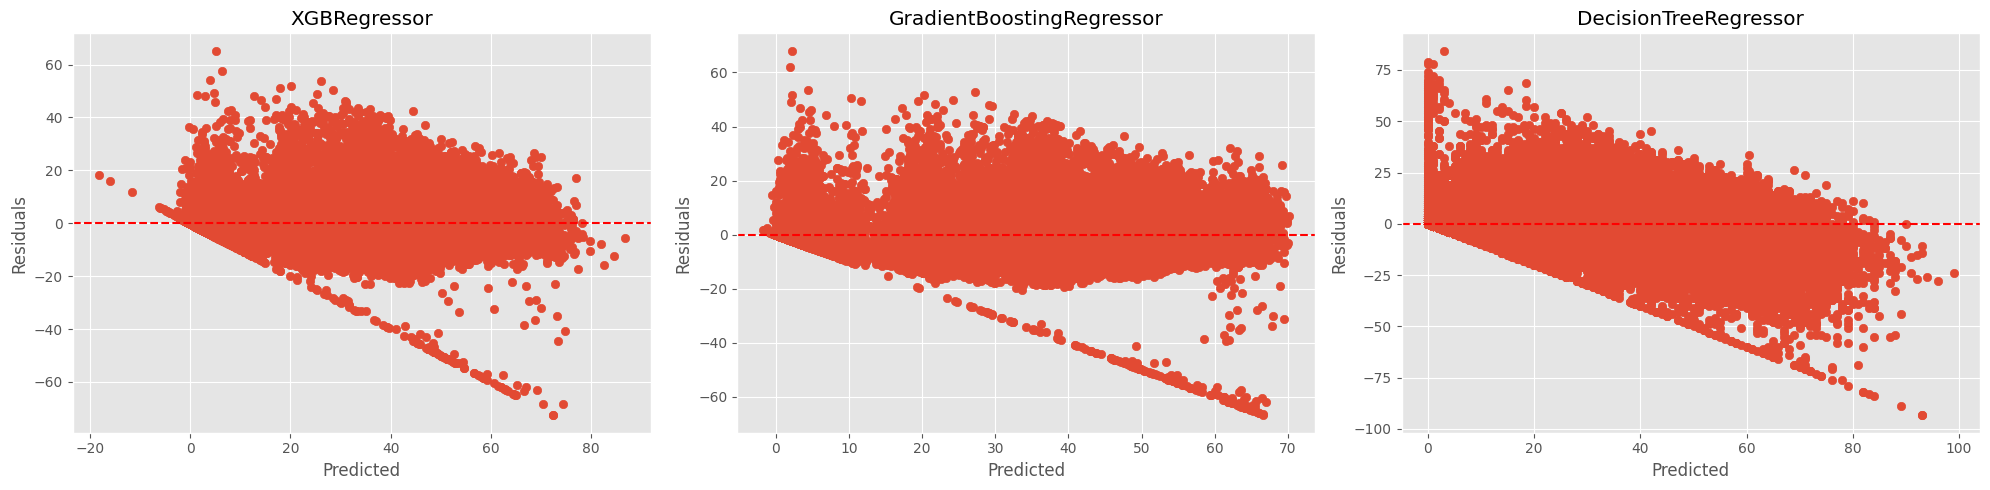

In [ ]:
fig, axes = subplots(1, 3, figsize=(20, 5))  

residuals_xgb = y_test - XGBRegressor_model.predict(x_test)
axes[0].scatter(XGBRegressor_model.predict(x_test), residuals_xgb)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title("XGBRegressor")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residuals")

residuals_lr = y_test - GradientBoostingRegressor_model.predict(x_test)
axes[1].scatter(GradientBoostingRegressor_model.predict(x_test), residuals_lr)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title("GradientBoostingRegressor")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residuals")

residuals_dt = y_test - DecisionTreeRegressor_model.predict(x_test)
axes[2].scatter(DecisionTreeRegressor_model.predict(x_test), residuals_dt)
axes[2].axhline(y=0, color='red', linestyle='--')
axes[2].set_title("DecisionTreeRegressor")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Residuals")

tight_layout()
show()

#### **Comparison and Insights:**

- ##### **XGBRegressor** and **GradientBoostingRegressor** show somewhat similar patterns, suggesting that while they are generally good, they both struggle a bit with higher predicted values, tending to underpredict them and showing some heteroscedasticity. XGBoost seems to handle this slightly better than GradientBoostingRegressor, as its bias at higher predicted values appears less severe than that of GradientBoostingRegressor, which aligns with its better performance metrics (R2, RMSE, MAE).
- ##### **DecisionTreeRegressor** performs significantly worse in terms of residual distribution. The distinct "steps" and pronounced fanning-out are strong indicators that this model is not a good fit for the data. This visual analysis strongly supports the quantitative metrics (lower R2, higher RMSE, and MAE) seen earlier for the DecisionTreeRegressor.

----------------------------------

## **Neural Network**

---------------------------

In [ ]:
scaler = StandardScaler() 
X_train = scaler.fit_transform(x_train) 
X_test = scaler.transform(x_test) 

In [ ]:
# Building Neural Network
model = Sequential([ 
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)), 
    Dense(128, activation='relu'), 
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation = 'linear')
    ])

In [ ]:
model.compile( 
    optimizer=Adam(learning_rate=0.0001), 
    loss='mse', 
    metrics=['mae'])

In [ ]:
early_stopping = EarlyStopping( 
    monitor='val_loss', 
    patience=2,          
    restore_best_weights=True 
    )

In [ ]:
# Model training
history = model.fit( 
    X_train, y_train, 
    validation_data=(X_test, y_test), 
    steps_per_epoch = 100,
    epochs=30, 
    batch_size=100, 
    verbose=1, 
    callbacks=[early_stopping])

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 1389.3015 - mae: 30.6632 - val_loss: 1192.2393 - val_mae: 28.7439
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 1028.3175 - mae: 26.8019 - val_loss: 493.7439 - val_mae: 18.8517
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 416.2991 - mae: 17.0657 - val_loss: 297.6815 - val_mae: 14.1381
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 293.3193 - mae: 13.9585 - val_loss: 252.9176 - val_mae: 12.9646
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 248.2129 - mae: 12.8530 - val_loss: 221.7953 - val_mae: 12.0500
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 222.8049 - mae: 11.9833 - val_loss: 193.5671 - val_mae: 11.0969
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 194.5943 - mae: 11.0088 - val_loss: 171.1673 - val_mae: 10.1399
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 171.9338 - mae: 10.0833 - val_loss: 153.7875 - val_mae: 9.437

In [ ]:
# Model evaluation
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0) 
print(f"Test Loss (MSE): {test_loss:.4f}") 
print(f"Test MAE: {test_mae:.4f}") 

Test Loss (MSE): 110.6830
Test MAE: 7.4653


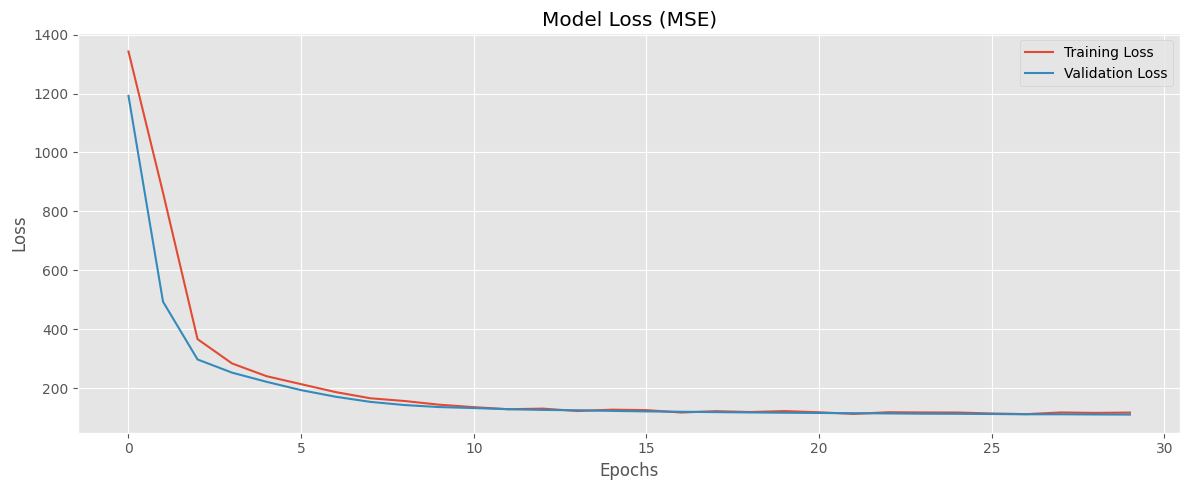

In [ ]:
figure(figsize=(12, 5)) 
 
plot(history.history['loss'], label='Training Loss') 
plot(history.history['val_loss'], label='Validation Loss') 
title('Model Loss (MSE)') 
xlabel('Epochs') 
ylabel('Loss') 
legend() 
 
tight_layout() 
show() 

- ##### **Rapid Decrease at the Beginning:** Both losses (training and validation) start at very high values and decrease very quickly within the first few epochs (approximately epochs 0 to 5). This indicates excellent and effective initial learning by the model.

- ##### **Stable and Smooth Training:** After the initial sharp drop, both lines (training loss and validation loss) become remarkably smooth and stable. The large fluctuations observed in previous training loss graphs have disappeared. This indicates a much more stable and effective training process.

- ##### **Close Convergence:** Both losses converge very closely. They quickly stabilize around an MSE value of 150-200, then gradually decrease further, eventually settling around 100-120 after approximately epoch 10-15.

- ##### **Correct Relationship Between the Two Losses:** The training loss and validation loss track each other very closely. The validation loss is slightly higher than the training loss, which is the typical and desired behavior (as the training data has been seen by the model, making its loss slightly lower). There is no clear sign of overfitting as the validation loss does not significantly increase while the training loss decreases.

- ##### **Reaching a Plateau Stage:** After approximately epoch 15, both losses appear to have largely reached a stable plateau. Any additional training beyond this point will yield minimal further improvement.

1067/1067 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


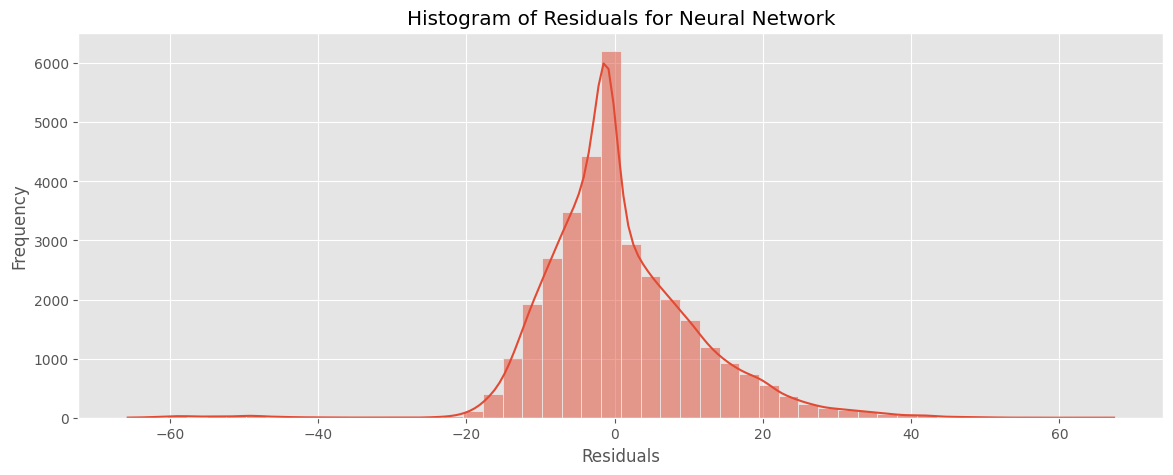

In [ ]:
y_pred_nn = model.predict(X_test).flatten() 

residuals_nn = y_test - y_pred_nn

figure(figsize=(14, 5))
histplot(residuals_nn, kde=True, bins=50)
title('Histogram of Residuals for Neural Network')
xlabel('Residuals')
ylabel('Frequency')
show()

- ##### **Centered around Zero**: The peak of the distribution is sharply centered at zero. This is an excellent sign, indicating that your Neural Network is unbiased; on average, it's not systematically over-predicting or under-predicting the target variable.
- ##### **Shape and Spread**: The distribution is mostly symmetrical and bell-shaped, resembling a normal distribution, which is generally desirable. However, it's quite peaked (leptokurtic) around zero, meaning a large number of predictions are very accurate (residuals close to zero).
- ##### **Tails**: The distribution also has "tails" extending to approximately -60 and +60. This indicates that while most predictions are accurate, there are still some instances where the model makes larger errors, both under-predicting (negative residuals) and over-predicting (positive residuals).

----------------------------------


# <center><strong>Conclusion</strong></center>
--------------------------------------------
#### **Based on the analysis,Neural Network is a highly suitable and effective solution for regression problem, demonstrating competitive-to-superior performance against boosting models, achieving remarkable training stability and efficiency with no signs of overfitting, and delivering unbiased predictions centered around zero. While the model is performing very well and generalizing effectively, the plateauing validation loss suggests it has likely reached the performance limits of its current architecture and hyperparameters, with some larger prediction errors still present in the tails of the residual distribution.**

---------------------------------------

In [ ]:
# !jupyter nbconvert --to html "Music_recommendation_system_regression.ipynb"

[NbConvertApp] Converting notebook Music_recommendation_system_regression.ipynb to html
C:\Users\RPC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
[NbConvertApp] WARNING | Alternative text is missing on 46 image(s).
[NbConvertApp] Writing 4064762 bytes to Music_recommendation_system_regression.html
